# Tricura ML Case
**Predicting Hospital Admission Risk (30-day horizon)**

**Author:** Johnattan Lima Santana

**Date:** 2026-03-08

This notebook builds a machine learning pipeline to predict whether a resident will have a hospital admission within the next 30 days.

**Pipeline steps:**
1. Environment setup
2. Data loading
3. Data exploration
4. Panel dataset construction
5. Feature engineering
6. Train/validation split
7. Model preparation
8. Conclusions

# 1. Environment Setup
Install dependencies and initialize the analysis environment.

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn duckdb pyarrow
!pip install graphviz # Detect potential relationships # Draw a diagram

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import duckdb
from pathlib import Path

from graphviz import Digraph

# 2. Data Loading
Load all parquet datasets and store them in a dictionary.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/tricura_case_data/"

In [ ]:
import os

os.listdir(DATA_PATH)

['therapy_tracks.parquet',
 'gg_responses.parquet',
 'injuries.parquet',
 'care_plans.parquet',
 'incidents.parquet',
 'document_tags.parquet',
 'adl_responses.parquet',
 'needs.parquet',
 'residents.parquet',
 'physician_orders.parquet',
 'vitals.parquet',
 'hospital_transfers.parquet',
 'factors.parquet',
 'medications.parquet',
 'diagnoses.parquet',
 'lab_reports.parquet',
 'hospital_admissions.parquet']

In [ ]:
tables = {}

for file in Path(DATA_PATH).glob("*.parquet"):
    name = file.stem
    tables[name] = pd.read_parquet(file)

print(tables.keys())

In [ ]:
# Function to display table headers
def show_heads(table_names, tables_dict, n=5):
    """
    Displays the first n rows of the selected tables.

    Parameters
    ----------
    table_names : list
        List of table names to display.
    tables_dict : dict
        Dictionary containing the loaded tables.
    n : int
        Number of rows to display (default = 5).
    """

    for name in table_names:
        print("="*60)
        print(f"{name.upper()} — first {n} rows")
        print("="*60)
        display(tables_dict[name].head(n))

# 3. Data Exploration
Initial inspection of datasets including structure, shapes, and categorical values.

In [ ]:
# Function to display table structure and data types
def show_info(table_names, tables_dict):
    """
    Displays the .info() summary of the selected tables.

    Parameters
    ----------
    table_names : list
        List of table names to display.
    tables_dict : dict
        Dictionary containing the loaded tables.
    """

    for name in table_names:
        print("="*60)
        print(f"{name.upper()} — table info")
        print("="*60)
        tables_dict[name].info()
        print("\n")

In [ ]:
# Function to display table dimensions
def show_shapes(table_names, tables_dict):
    """
    Displays the number of rows and columns of the selected tables.

    Parameters
    ----------
    table_names : list
        List of table names to display.
    tables_dict : dict
        Dictionary containing the loaded tables.
    """

    for name in table_names:
        df = tables_dict[name]
        print(f"{name}: {df.shape[0]} rows × {df.shape[1]} columns")

In [ ]:
# Function to display unique values for selected columns with limit
def show_unique_values(tables_dict, table_columns, limit=20):
    """
    Displays unique values for specified columns in specified tables,
    limiting the output to avoid excessive printing.

    Parameters
    ----------
    tables_dict : dict
        Dictionary containing the loaded tables.

    table_columns : dict
        Mapping of table names to lists of column names.

    limit : int
        Maximum number of unique values to display.
    """

    for table, columns in table_columns.items():
        df = tables_dict[table]

        print("="*60)
        print(f"TABLE: {table}")
        print("="*60)

        for col in columns:

            unique_vals = df[col].dropna().unique()
            total_unique = len(unique_vals)

            print(f"\nColumn: {col}")
            print(f"Total unique values: {total_unique}")

            if total_unique > limit:
                print(f"Showing first {limit} values:")
                print(unique_vals[:limit])
            else:
                print(unique_vals)

# EXAMPLE:

#   show_unique_values(
#     tables,
#     {
#         "incidents": ["incident_type", "severity"],
#         "residents": ["gender"]
#     }
# )

In [ ]:
# Function to generate a full dataset summary
def generate_data_dictionary(tables_dict, label_limit=60):

    rows = []

    for table_name, df in tables_dict.items():

        for col in df.columns:

            dtype = str(df[col].dtype)

            cardinality = df[col].nunique(dropna=True)
            missing = df[col].isna().sum()
            missing_pct = df[col].isna().mean()

            labels = None
            min_val = None
            max_val = None

            # categorical-like
            if dtype in ["object", "category", "bool"]:

                if cardinality <= label_limit:
                    labels = ", ".join(
                        map(str, sorted(df[col].dropna().unique()))
                    )

            # numeric
            elif "int" in dtype or "float" in dtype:

                min_val = df[col].min()
                max_val = df[col].max()

            # datetime
            elif "datetime" in dtype:

                min_val = df[col].min()
                max_val = df[col].max()

            rows.append({
                "table": table_name,
                "column": col,
                "dtype": dtype,
                "cardinality": cardinality,
                "missing_values": missing,
                "missing_pct": round(missing_pct, 4),
                "min_value": min_val,
                "max_value": max_val,
                "labels": labels
            })

    summary = pd.DataFrame(rows)

    return summary.sort_values(["table", "column"])

## 3.1 Table Preview

In [ ]:
#show_heads(["incidents", "residents", "vitals"], tables)
show_heads(list(tables.keys()), tables) # show all

In [ ]:
# #tables["incidents"].info()
# tables["vitals"].info()

# 4. Data Summary




In [ ]:
#analyze_categorical_columns(tables)
generate_data_dictionary(tables)

,table,column,dtype,cardinality,missing_values,missing_pct,min_value,max_value,labels
54,adl_responses,activity,object,22,0,0.0,None,None,"Bathing - Self-Performance, Bathing - Support,..."
60,adl_responses,adl_change,int64,9,0,0.0,-4,4,None
50,adl_responses,adl_response_id,object,480554,0,0.0,None,None,None
53,adl_responses,assessment_date,datetime64[us],281,0,0.0,2024-04-26 00:00:00,2025-01-31 00:00:00,None
55,adl_responses,category,object,2,0,0.0,None,None,"Self-Performance, Support"
...,...,...,...,...,...,...,...,...,...
93,vitals,resident_id,object,2464,0,0.0,None,None,None
99,vitals,strikeout,bool,2,0,0.0,None,None,"False, True"
96,vitals,value,float64,3347,0,0.0,0.0,19999.0,None
92,vitals,vital_id,object,2517056,0,0.0,None,None,None


# 5. Data Relationships
Automatic detection of potential foreign-key relationships between tables.




In [ ]:
# Detect potential relationships
# Draw a diagram

# ------------------------------------------------------------
# Function: detect_relationships_smart
# ------------------------------------------------------------
# This function attempts to automatically detect possible
# relationships between tables by analyzing the overlap
# of values between columns.
#
# The logic assumes that if most values in column A
# appear inside column B, then A may be a foreign key
# referencing B.
#
# Example:
# claims.policy_id → policies.policy_id
# ------------------------------------------------------------

def detect_relationships_smart(
    tables_dict,
    min_unique=20,
    min_inclusion=0.9,
    max_sample=5000
):

    # --------------------------------------------------------
    # These terms help identify columns that likely represent
    # keys (IDs, codes, identifiers, etc.)
    # This reduces noise by ignoring irrelevant columns.
    # --------------------------------------------------------
    key_terms = ["id", "_id", "code", "key", "number", "no"]

    # This list will store candidate columns that could
    # potentially participate in relationships.
    candidates = []

    # --------------------------------------------------------
    # STEP 1 — Identify candidate key columns
    # --------------------------------------------------------
    # We iterate through every table and every column,
    # selecting only columns that look like identifiers.
    # --------------------------------------------------------

    for table_name, df in tables_dict.items():

        for col in df.columns:

            col_lower = col.lower()

            # ------------------------------------------------
            # Skip columns that do not look like keys
            # (based on their name)
            # ------------------------------------------------
            if not any(term in col_lower for term in key_terms):
                continue

            # Remove missing values before analysis
            s = df[col].dropna()

            if len(s) == 0:
                continue

            # Count unique values in the column
            nunique = s.nunique()

            # Ignore columns with very low variability
            # (for example: status codes, flags, etc.)
            if nunique < min_unique:
                continue

            # ------------------------------------------------
            # To keep the algorithm efficient,
            # we sample values if the column is very large.
            # ------------------------------------------------
            sampled = s.astype(str).drop_duplicates()

            if len(sampled) > max_sample:
                sampled = sampled.sample(max_sample, random_state=42)

            # Store this column as a candidate for relationship detection
            candidates.append({
                "table": table_name,
                "column": col,
                "nunique": nunique,
                "values": set(sampled.tolist())
            })

    # --------------------------------------------------------
    # STEP 2 — Compare candidate columns between tables
    # --------------------------------------------------------
    # We now compare every candidate column against every
    # other candidate column from a different table.
    # --------------------------------------------------------

    relationships = []

    for a in candidates:
        for b in candidates:

            # Skip comparisons within the same table
            if a["table"] == b["table"]:
                continue

            if len(a["values"]) == 0 or len(b["values"]) == 0:
                continue

            # ------------------------------------------------
            # Calculate how many values from column A
            # also exist in column B
            # ------------------------------------------------
            overlap = a["values"] & b["values"]

            inclusion = len(overlap) / len(a["values"])

            # ------------------------------------------------
            # If most values from A appear in B,
            # we assume A may reference B
            # ------------------------------------------------
            if inclusion >= min_inclusion:

                relationships.append({
                    "from_table": a["table"],
                    "from_column": a["column"],
                    "to_table": b["table"],
                    "to_column": b["column"],
                    "inclusion_score": round(inclusion, 4),
                    "from_nunique": a["nunique"],
                    "to_nunique": b["nunique"]
                })

    # Convert results to DataFrame
    rel_df = pd.DataFrame(relationships)

    # If no relationships were detected, return empty result
    if rel_df.empty:
        return rel_df

    # --------------------------------------------------------
    # STEP 3 — Remove duplicated relationships
    # --------------------------------------------------------
    # Keep the strongest relationships based on:
    # - inclusion score
    # - number of unique values
    # --------------------------------------------------------
    rel_df = (
        rel_df.sort_values(["inclusion_score", "from_nunique"], ascending=[False, False])
              .drop_duplicates(subset=["from_table", "from_column", "to_table", "to_column"])
              .reset_index(drop=True)
    )

    return rel_df

In [ ]:
# ------------------------------------------------------------
# Run the relationship detection algorithm on all loaded tables
# ------------------------------------------------------------

relationships_df = detect_relationships_smart(tables)

# Display detected relationships
relationships_df

,from_table,from_column,to_table,to_column,inclusion_score,from_nunique,to_nunique
0,therapy_tracks,resident_id,residents,resident_id,1.0000,219,3000
1,gg_responses,resident_id,needs,resident_id,1.0000,134,2490
2,gg_responses,resident_id,residents,resident_id,1.0000,134,3000
3,gg_responses,resident_id,care_plans,resident_id,1.0000,134,2745
4,gg_responses,resident_id,document_tags,resident_id,1.0000,134,1018
...,...,...,...,...,...,...,...
216,diagnoses,facility_id,physician_orders,facility_id,0.9091,99,90
217,care_plans,resident_id,needs,resident_id,0.9046,2745,2490
218,care_plans,facility_id,physician_orders,facility_id,0.9000,100,90
219,needs,facility_id,physician_orders,facility_id,0.9000,100,90


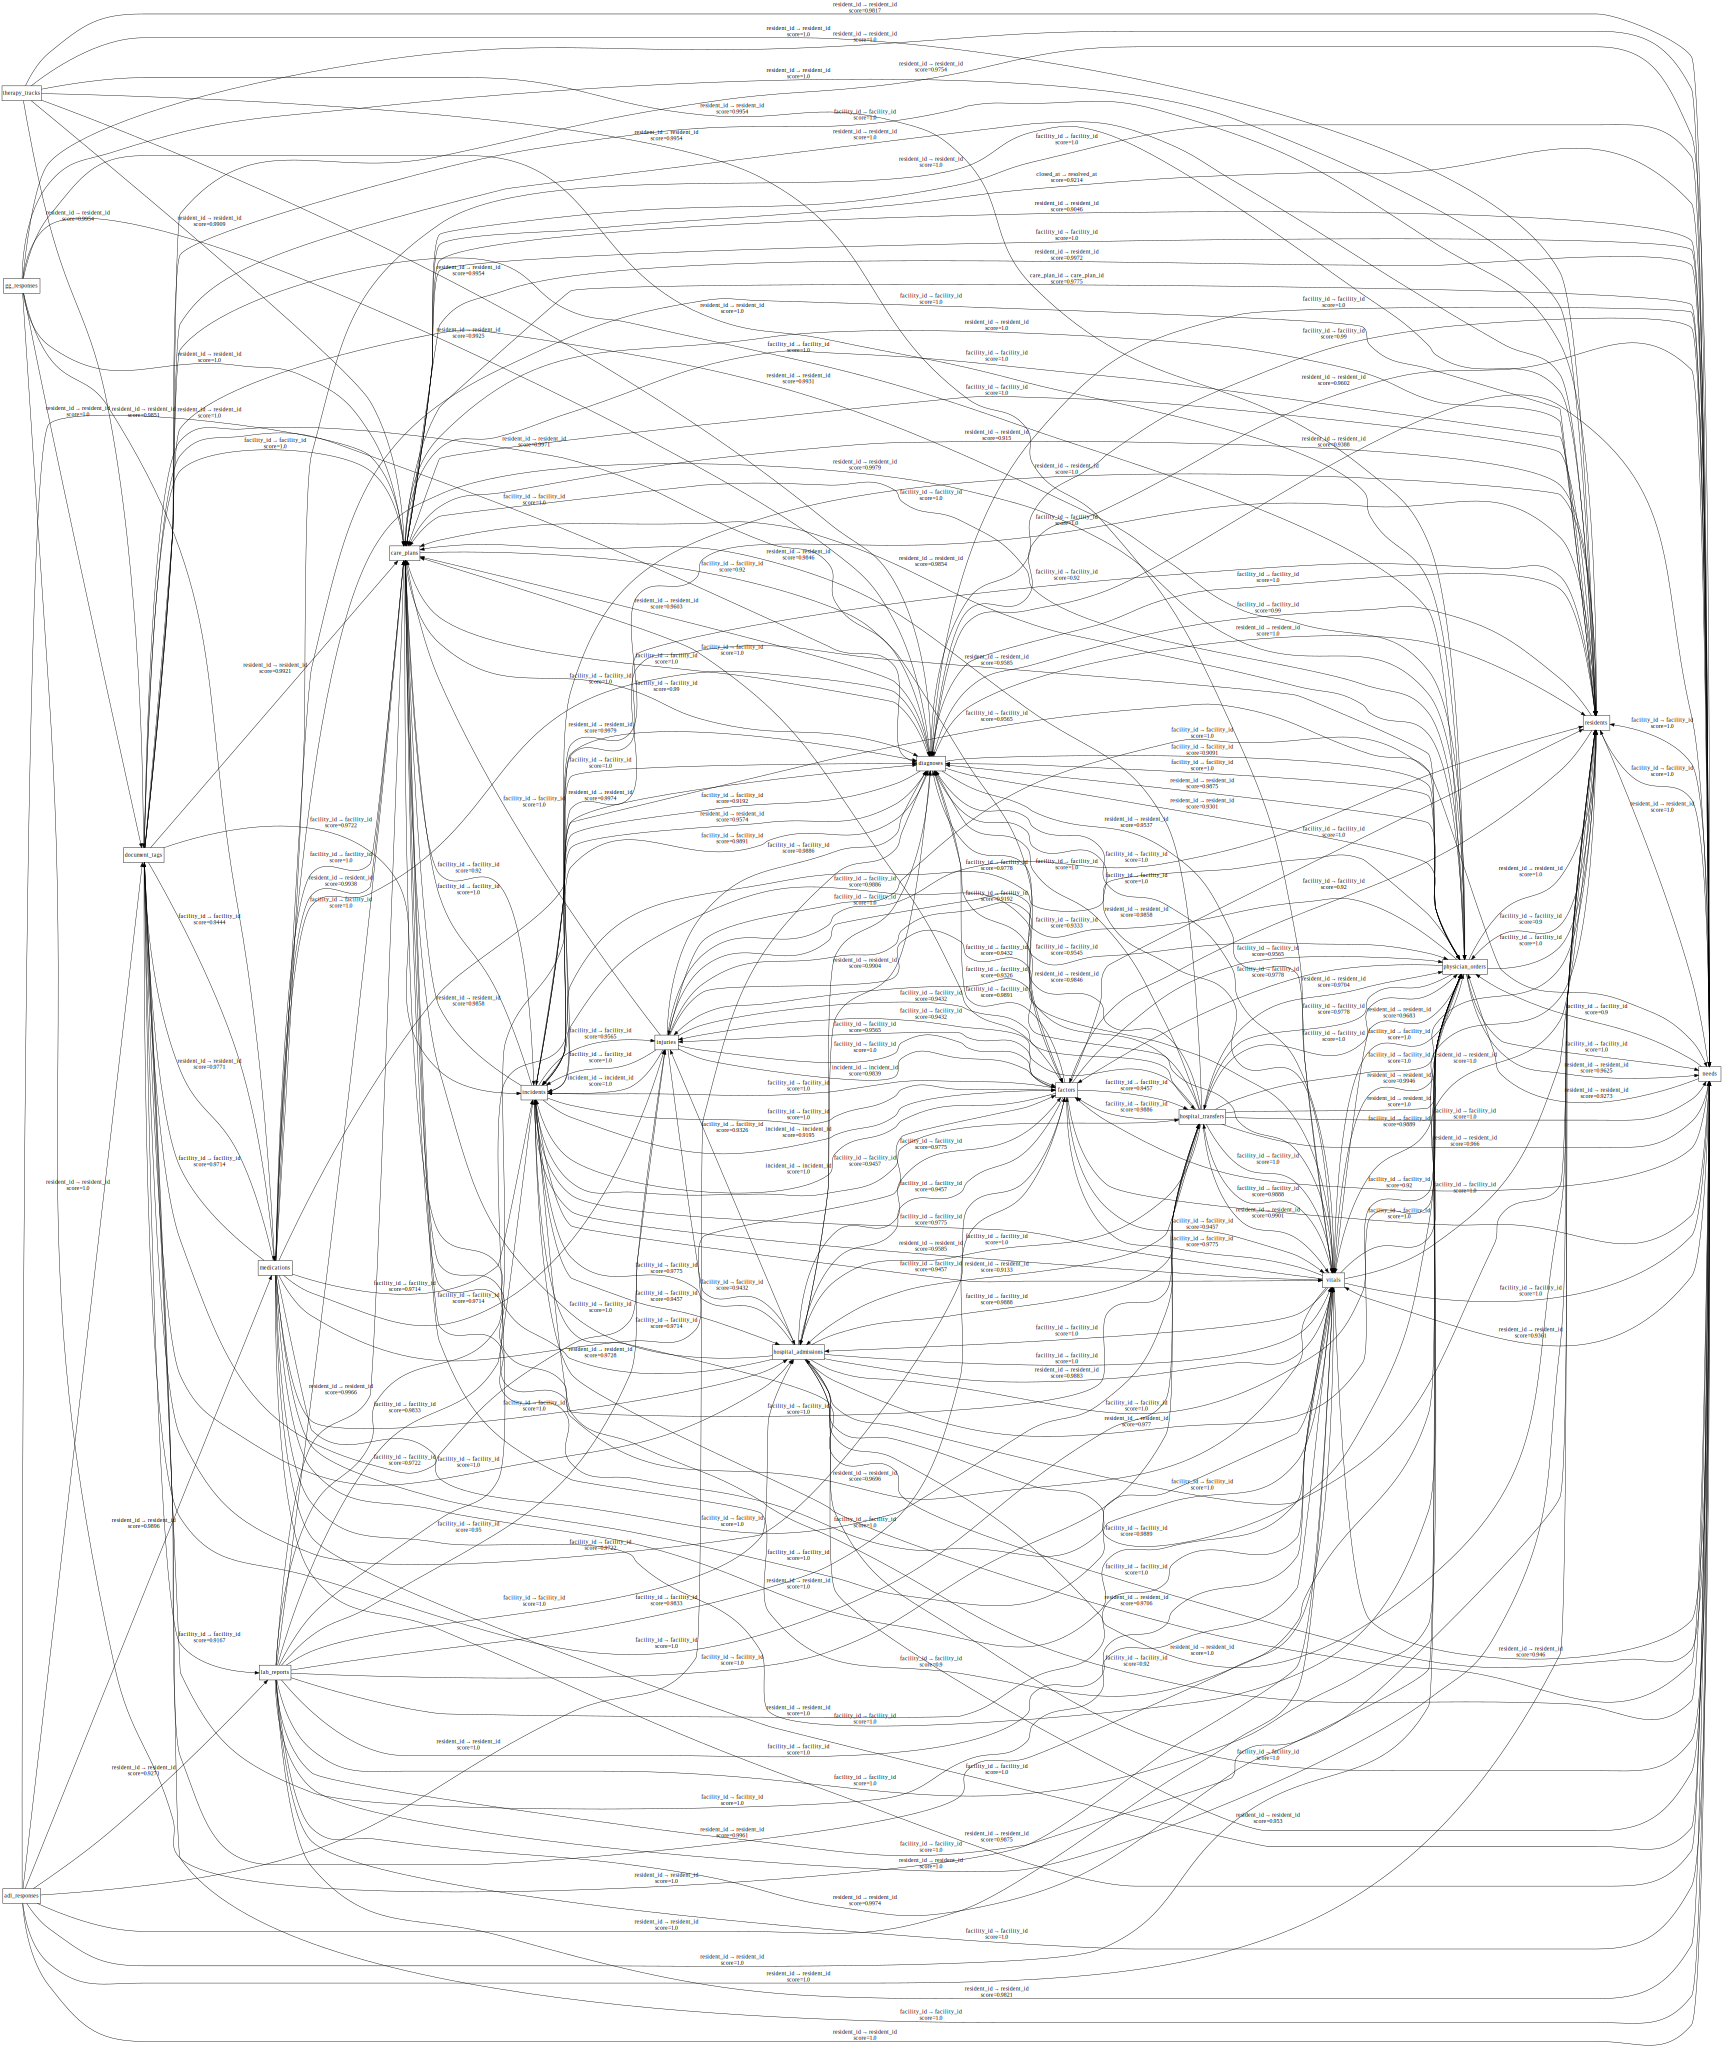

In [ ]:
# ------------------------------------------------------------
# Create a Graphviz diagram to visually represent
# the relationships between tables.
# ------------------------------------------------------------

dot = Digraph(format="png")

# Set diagram orientation (Left → Right)
dot.attr(rankdir="LR")

# ------------------------------------------------------------
# STEP 1 — Add tables as nodes in the diagram
# ------------------------------------------------------------
for table_name in tables.keys():
    dot.node(table_name, table_name, shape="box")

# ------------------------------------------------------------
# STEP 2 — Add edges representing detected relationships
# ------------------------------------------------------------
for _, row in relationships_df.iterrows():

    # Label includes the columns involved in the relationship
    # and the inclusion score detected by the algorithm
    label = f'{row["from_column"]} → {row["to_column"]}\nscore={row["inclusion_score"]}'

    dot.edge(row["from_table"], row["to_table"], label=label)

# Display the ERD diagram
dot

# 6. ERD

In [ ]:
# ------------------------------------------------------------
# Export the ERD diagram to a PNG file
# This file can be shared with collaborators
# ------------------------------------------------------------

dot.render("erd_auto_detected", cleanup=True)

'erd_auto_detected.png'

In [ ]:
# ------------------------------------------------------------
# Save detected relationships to a CSV file
# This helps document possible joins between tables
# ------------------------------------------------------------

relationships_df.to_csv("possible_relationships.csv", index=False)

#7. First Key-Questions

In [ ]:
#How many residents are there?
print("How many residents are there?")
print(tables["residents"]["resident_id"].nunique())

#How many hospital admissions?
print("How many hospital admissions?")
print(tables["hospital_admissions"].shape)

#Hospitalization rate
print("Hospitalization rate")
admissions = tables["hospital_admissions"]
print(admissions["resident_id"].nunique() / tables["residents"]["resident_id"].nunique())

#Are events rare?
print("Are events rare? \n Note: If <5% we have class imbalance")

#Temporal distribution
tables["hospital_admissions"]["effective_date"].describe()



How many residents are there?
3000
How many hospital admissions?
(2945, 9)
Hospitalization rate
0.6243333333333333
Are events rare? 
 Note: If <5% we have class imbalance


,effective_date
count,2945
mean,2024-02-25 09:19:20.699490
min,2005-02-23 14:35:00
25%,2023-11-28 15:30:00
50%,2024-04-18 15:53:00
75%,2024-09-06 19:11:00
max,2025-01-31 14:58:00


# 8. Target Definition
Define the prediction objective: hospital admission within 30 days.

## 8.1 Dataset Inspection

In [ ]:
#checking column names
for t in ["residents", "hospital_admissions", "incidents"]:
    print("\n", t)
    print(tables[t].columns.tolist())


 residents
['resident_id', 'facility_id', 'date_of_birth', 'admission_date', 'discharge_date', 'deceased_date', 'outpatient', 'created_at', 'updated_at']

 hospital_admissions
['admission_id', 'facility_id', 'resident_id', 'effective_date', 'ineffective_date', 'admission_status', 'emergency_flag', 'hospital_stay_to', 'created_at']

 incidents
['incident_id', 'facility_id', 'resident_id', 'incident_type', 'incident_location', 'occurred_at', 'strikeout', 'created_at']


## 8.2 Target Construction

In [ ]:
# ------------------------------------------------------------
# 9. Configuration for target creation
# ------------------------------------------------------------
# This block defines the key tables and columns that will be
# used to build the modeling base and the prediction target.
# ------------------------------------------------------------

CONFIG = {
    # Main resident table
    "resident_table": "residents",
    "resident_id_col": "resident_id",

    # Target event table: hospital admissions
    "target_event_table": "hospital_admissions",
    "target_event_date_col": "effective_date",

    # Resident lifecycle columns
    "resident_start_date_col": "admission_date",
    "resident_end_date_col": "discharge_date",
    "resident_deceased_date_col": "deceased_date",

    # Final binary target name
    "target_name": "hospital_admission_within_30_days",

    # Prediction horizon in days
    "prediction_window_days": 30
}

In [ ]:
# ------------------------------------------------------------
# 9.1 Standardize datetime columns
# ------------------------------------------------------------
# This helper safely converts date-like columns to pandas
# datetime format, avoiding downstream issues in time logic.
# ------------------------------------------------------------

def ensure_datetime(df, col):
    if col is not None and col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

# Convert datetime columns in residents table
for col in [
    "date_of_birth",
    "admission_date",
    "discharge_date",
    "deceased_date",
    "created_at",
    "updated_at"
]:
    if col in tables["residents"].columns:
        tables["residents"] = ensure_datetime(tables["residents"], col)

# Convert datetime columns in hospital_admissions table
for col in [
    "effective_date",
    "ineffective_date",
    "hospital_stay_to",
    "created_at"
]:
    if col in tables["hospital_admissions"].columns:
        tables["hospital_admissions"] = ensure_datetime(tables["hospital_admissions"], col)

# Convert datetime columns in incidents table
for col in [
    "occurred_at",
    "created_at"
]:
    if col in tables["incidents"].columns:
        tables["incidents"] = ensure_datetime(tables["incidents"], col)

## 8.3 Panel Dataset Construction
Transform event tables into a resident-month panel suitable for machine learning.

In [ ]:
# ------------------------------------------------------------
# 10. Build resident-month panel
# ------------------------------------------------------------
# This creates one row per resident per month while the resident
# is active in the dataset.
#
# Active period:
# - starts at residents.admission_date
# - ends at the earliest available end date between:
#   discharge_date, deceased_date
# - if no end date exists, the resident remains active until
#   the maximum observed target event date in the dataset
# ------------------------------------------------------------

import pandas as pd
import numpy as np

resident_id_col = CONFIG["resident_id_col"]
target_name = CONFIG["target_name"]

residents_df = tables["residents"].copy()
hospital_df = tables["hospital_admissions"].copy()

# Keep only relevant columns from residents
residents_df = residents_df[[
    "resident_id",
    "facility_id",
    "admission_date",
    "discharge_date",
    "deceased_date",
    "date_of_birth",
    "outpatient"
]].drop_duplicates()

# Define the latest observed hospital admission date in the dataset
global_max_event_date = hospital_df["effective_date"].max()

# Create an end-of-observation column for each resident
# This uses the earliest valid end date (discharge or death);
# if neither exists, use the dataset's maximum event date.
residents_df["resident_active_until"] = residents_df[
    ["discharge_date", "deceased_date"]
].min(axis=1)

residents_df["resident_active_until"] = residents_df["resident_active_until"].fillna(global_max_event_date)

# Remove residents with missing admission_date because we cannot
# define when their observation period starts
residents_df = residents_df.dropna(subset=["admission_date"]).copy()

# Convert start/end dates to month starts
residents_df["start_month"] = residents_df["admission_date"].dt.to_period("M").dt.to_timestamp()
residents_df["end_month"] = residents_df["resident_active_until"].dt.to_period("M").dt.to_timestamp()

# Keep only valid periods
residents_df = residents_df[residents_df["start_month"] <= residents_df["end_month"]].copy()

# Build one row per resident-month
panel_rows = []

for _, row in residents_df.iterrows():
    months = pd.date_range(row["start_month"], row["end_month"], freq="MS")

    for month in months:
        panel_rows.append({
            "resident_id": row["resident_id"],
            "facility_id": row["facility_id"],
            "snapshot_month": month,
            "date_of_birth": row["date_of_birth"],
            "outpatient": row["outpatient"],
            "resident_admission_date": row["admission_date"],
            "resident_discharge_date": row["discharge_date"],
            "resident_deceased_date": row["deceased_date"]
        })

panel = pd.DataFrame(panel_rows)

print("Resident-month panel shape:", panel.shape)
display(panel.head())

Resident-month panel shape: (33430, 8)


,resident_id,facility_id,snapshot_month,date_of_birth,outpatient,resident_admission_date,resident_discharge_date,resident_deceased_date
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-10-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-11-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-12-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-01-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-02-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT


In [ ]:
# ------------------------------------------------------------
# 10.1 Create binary target: hospital admission within next 30 days
# ------------------------------------------------------------
# For each resident-month, this target equals 1 if the resident
# has at least one hospital admission in the next 30 days after
# the snapshot month.
#
# Important:
# - only future admissions are used
# - this avoids target leakage
# ------------------------------------------------------------

window_days = CONFIG["prediction_window_days"]

target_events = hospital_df[[
    "resident_id",
    "effective_date"
]].dropna().copy()

panel_target = panel.merge(
    target_events,
    on="resident_id",
    how="left"
)

# Define the future prediction window
panel_target["window_end"] = panel_target["snapshot_month"] + pd.Timedelta(days=window_days)

# Mark whether a hospital admission occurs in the future window
panel_target["is_target_event"] = (
    (panel_target["effective_date"] > panel_target["snapshot_month"]) &
    (panel_target["effective_date"] <= panel_target["window_end"])
).astype(int)

# Aggregate back to one row per resident-month
target_df = (
    panel_target
    .groupby(["resident_id", "snapshot_month"], as_index=False)["is_target_event"]
    .max()
    .rename(columns={"is_target_event": target_name})
)

panel = panel.merge(
    target_df,
    on=["resident_id", "snapshot_month"],
    how="left"
)

panel[target_name] = panel[target_name].fillna(0).astype(int)

print(panel[target_name].value_counts(dropna=False))
display(panel.head())

hospital_admission_within_30_days
0    31346
1     2084
Name: count, dtype: int64


,resident_id,facility_id,snapshot_month,date_of_birth,outpatient,resident_admission_date,resident_discharge_date,resident_deceased_date,hospital_admission_within_30_days
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-10-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-11-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-12-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-01-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-02-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0


## 8.4 Target Sanity Check

In [ ]:
# ------------------------------------------------------------
# 10.2 Sanity check for target prevalence
# ------------------------------------------------------------
# This block checks the overall target rate and how it varies
# by month, which helps validate whether target creation looks
# reasonable.
# ------------------------------------------------------------

overall_target_rate = panel[target_name].mean()
print(f"Overall target rate: {overall_target_rate:.4%}")

monthly_target_rate = (
    panel.groupby("snapshot_month")[target_name]
    .mean()
    .reset_index()
    .sort_values("snapshot_month")
)

display(monthly_target_rate.head(12))
display(monthly_target_rate.tail(12))

Overall target rate: 6.2339%


,snapshot_month,hospital_admission_within_30_days
0,2005-02-01,1.0
1,2005-03-01,0.0
2,2005-04-01,0.0
3,2005-05-01,0.0
4,2005-06-01,0.0
5,2005-07-01,0.0
6,2005-08-01,0.0
7,2005-09-01,0.0
8,2005-10-01,0.0
9,2005-11-01,0.0


,snapshot_month,hospital_admission_within_30_days
241,2025-03-01,0.0
242,2025-04-01,0.0
243,2025-05-01,0.0
244,2025-06-01,0.0
245,2025-07-01,0.0
246,2025-08-01,0.0
247,2025-09-01,0.0
248,2025-10-01,0.0
249,2025-11-01,0.0
250,2025-12-01,0.0


# 9. Feature Engineering

In [ ]:
# ------------------------------------------------------------
# 11.1 Historical feature: past hospital admissions count
# ------------------------------------------------------------
# For each resident-month, count the number of hospital
# admissions that occurred strictly before the snapshot month.
# ------------------------------------------------------------

admissions_df = hospital_df[[
    "resident_id",
    "effective_date",
    "emergency_flag",
    "admission_status"
]].dropna(subset=["resident_id", "effective_date"]).copy()

admissions_df = admissions_df.rename(columns={"effective_date": "hospital_admission_date"})

panel_adm = panel[["resident_id", "snapshot_month"]].merge(
    admissions_df,
    on="resident_id",
    how="left"
)

panel_adm["past_admission_flag"] = (
    panel_adm["hospital_admission_date"] < panel_adm["snapshot_month"]
).astype(int)

past_adm_count = (
    panel_adm.groupby(["resident_id", "snapshot_month"], as_index=False)["past_admission_flag"]
    .sum()
    .rename(columns={"past_admission_flag": "past_hospital_admissions_count"})
)

panel = panel.merge(
    past_adm_count,
    on=["resident_id", "snapshot_month"],
    how="left"
)

panel["past_hospital_admissions_count"] = panel["past_hospital_admissions_count"].fillna(0).astype(int)

display(panel.head())

,resident_id,facility_id,snapshot_month,date_of_birth,outpatient,resident_admission_date,resident_discharge_date,resident_deceased_date,hospital_admission_within_30_days,past_hospital_admissions_count
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-10-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-11-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-12-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-01-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-02-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0


In [ ]:
# ------------------------------------------------------------
# 11.2 Historical feature: past incidents count
# ------------------------------------------------------------
# For each resident-month, count the number of incidents that
# occurred strictly before the snapshot month.
# ------------------------------------------------------------

incidents_df = tables["incidents"].copy()

incidents_df = incidents_df[[
    "resident_id",
    "occurred_at",
    "incident_type",
    "incident_location",
    "strikeout"
]].dropna(subset=["resident_id", "occurred_at"]).copy()

incidents_df = incidents_df.rename(columns={"occurred_at": "incident_date"})

panel_inc = panel[["resident_id", "snapshot_month"]].merge(
    incidents_df,
    on="resident_id",
    how="left"
)

panel_inc["past_incident_flag"] = (
    panel_inc["incident_date"] < panel_inc["snapshot_month"]
).astype(int)

past_inc_count = (
    panel_inc.groupby(["resident_id", "snapshot_month"], as_index=False)["past_incident_flag"]
    .sum()
    .rename(columns={"past_incident_flag": "past_incidents_count"})
)

panel = panel.merge(
    past_inc_count,
    on=["resident_id", "snapshot_month"],
    how="left"
)

panel["past_incidents_count"] = panel["past_incidents_count"].fillna(0).astype(int)

display(panel.head())

,resident_id,facility_id,snapshot_month,date_of_birth,outpatient,resident_admission_date,resident_discharge_date,resident_deceased_date,hospital_admission_within_30_days,past_hospital_admissions_count,past_incidents_count
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-10-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-11-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-12-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-01-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-02-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0


In [ ]:
# ------------------------------------------------------------
# 11.3 Historical feature: days since last hospital admission
# ------------------------------------------------------------
# For each resident-month, compute the number of days since
# the most recent hospital admission before the snapshot month.
# Missing values indicate no prior admission.
# ------------------------------------------------------------

last_adm = panel[["resident_id", "snapshot_month"]].merge(
    admissions_df[["resident_id", "hospital_admission_date"]],
    on="resident_id",
    how="left"
)

last_adm = last_adm[
    last_adm["hospital_admission_date"] < last_adm["snapshot_month"]
].copy()

last_adm = (
    last_adm.groupby(["resident_id", "snapshot_month"], as_index=False)["hospital_admission_date"]
    .max()
    .rename(columns={"hospital_admission_date": "last_hospital_admission_date"})
)

panel = panel.merge(
    last_adm,
    on=["resident_id", "snapshot_month"],
    how="left"
)

panel["days_since_last_admission"] = (
    panel["snapshot_month"] - panel["last_hospital_admission_date"]
).dt.days

display(panel.head())

,resident_id,facility_id,snapshot_month,date_of_birth,outpatient,resident_admission_date,resident_discharge_date,resident_deceased_date,hospital_admission_within_30_days,past_hospital_admissions_count,past_incidents_count,last_hospital_admission_date,days_since_last_admission
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-10-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-11-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-12-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-01-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-02-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN


In [ ]:
# ------------------------------------------------------------
# 11.4 Historical feature: resident age at snapshot
# ------------------------------------------------------------
# This calculates the resident's age in years at each
# snapshot month using date_of_birth.
# ------------------------------------------------------------

panel["resident_age_years"] = (
    (panel["snapshot_month"] - panel["date_of_birth"]).dt.days / 365.25
)

display(panel[["resident_id", "snapshot_month", "date_of_birth", "resident_age_years"]].head())

,resident_id,snapshot_month,date_of_birth,resident_age_years
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-10-01,1936-04-15,81.462012
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-11-01,1936-04-15,81.546886
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-12-01,1936-04-15,81.629021
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-01-01,1936-04-15,81.713895
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-02-01,1936-04-15,81.798768


In [ ]:
# ------------------------------------------------------------
# 11.5 Historical feature: length of stay up to snapshot
# ------------------------------------------------------------
# This measures how many days the resident has been in the
# facility up to the snapshot month, based on the resident's
# original admission date.
#
# Because snapshot_month is defined as the first day of the month,
# residents admitted later in that same month may produce
# negative values. These cases are clipped to zero.
# ------------------------------------------------------------

panel["days_since_resident_admission"] = (
    panel["snapshot_month"] - panel["resident_admission_date"]
).dt.days

panel["days_since_resident_admission"] = panel["days_since_resident_admission"].clip(lower=0)

display(panel[["resident_id", "snapshot_month", "resident_admission_date", "days_since_resident_admission"]].head())

,resident_id,snapshot_month,resident_admission_date,days_since_resident_admission
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-10-01,2017-10-25 23:00:00,0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-11-01,2017-10-25 23:00:00,6
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-12-01,2017-10-25 23:00:00,36
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-01-01,2017-10-25 23:00:00,67
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-02-01,2017-10-25 23:00:00,98


In [ ]:
# ------------------------------------------------------------
# 11.6 Historical feature: past emergency admissions count
# ------------------------------------------------------------
# This counts how many past hospital admissions were marked
# as emergency admissions before the snapshot month.
# ------------------------------------------------------------

adm_emergency = panel[["resident_id", "snapshot_month"]].merge(
    admissions_df[["resident_id", "hospital_admission_date", "emergency_flag"]],
    on="resident_id",
    how="left"
)

adm_emergency["past_emergency_flag"] = (
    (adm_emergency["hospital_admission_date"] < adm_emergency["snapshot_month"]) &
    (adm_emergency["emergency_flag"] == True)
).astype(int)

past_emergency_count = (
    adm_emergency.groupby(["resident_id", "snapshot_month"], as_index=False)["past_emergency_flag"]
    .sum()
    .rename(columns={"past_emergency_flag": "past_emergency_admissions_count"})
)

panel = panel.merge(
    past_emergency_count,
    on=["resident_id", "snapshot_month"],
    how="left"
)

panel["past_emergency_admissions_count"] = panel["past_emergency_admissions_count"].fillna(0).astype(int)

display(panel.head())

,resident_id,facility_id,snapshot_month,date_of_birth,outpatient,resident_admission_date,resident_discharge_date,resident_deceased_date,hospital_admission_within_30_days,past_hospital_admissions_count,past_incidents_count,last_hospital_admission_date,days_since_last_admission,resident_age_years,days_since_resident_admission,past_emergency_admissions_count
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-10-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.462012,-25,0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-11-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.546886,6,0
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-12-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.629021,36,0
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-01-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.713895,67,0
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-02-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.798768,98,0


In [ ]:
# ------------------------------------------------------------
# 11.7 Historical feature: past strikeout incidents count
# ------------------------------------------------------------
# This counts how many prior incidents were marked as strikeout
# before the snapshot month.
# ------------------------------------------------------------

inc_strikeout = panel[["resident_id", "snapshot_month"]].merge(
    incidents_df[["resident_id", "incident_date", "strikeout"]],
    on="resident_id",
    how="left"
)

inc_strikeout["past_strikeout_flag"] = (
    (inc_strikeout["incident_date"] < inc_strikeout["snapshot_month"]) &
    (inc_strikeout["strikeout"] == True)
).astype(int)

past_strikeout_count = (
    inc_strikeout.groupby(["resident_id", "snapshot_month"], as_index=False)["past_strikeout_flag"]
    .sum()
    .rename(columns={"past_strikeout_flag": "past_strikeout_incidents_count"})
)

panel = panel.merge(
    past_strikeout_count,
    on=["resident_id", "snapshot_month"],
    how="left"
)

panel["past_strikeout_incidents_count"] = panel["past_strikeout_incidents_count"].fillna(0).astype(int)

display(panel.head())

,resident_id,facility_id,snapshot_month,date_of_birth,outpatient,resident_admission_date,resident_discharge_date,resident_deceased_date,hospital_admission_within_30_days,past_hospital_admissions_count,past_incidents_count,last_hospital_admission_date,days_since_last_admission,resident_age_years,days_since_resident_admission,past_emergency_admissions_count,past_strikeout_incidents_count
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-10-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.462012,-25,0,0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-11-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.546886,6,0,0
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-12-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.629021,36,0,0
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-01-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.713895,67,0,0
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-02-01,1936-04-15,False,2017-10-25 23:00:00,NaT,NaT,0,0,0,NaT,NaN,81.798768,98,0,0


In [ ]:
# ------------------------------------------------------------
# 11.8 Remove months without full prediction window
# ------------------------------------------------------------
# The final months in the dataset may not have a full
# future window available (e.g., 30 days) to observe
# the target event.
#
# For example:
# if the last hospital admission occurred on 2026-02-10
# we cannot evaluate a prediction made on 2026-02-01
# because the full 30-day horizon is not observable.
#
# Therefore, we remove rows where snapshot_month is too
# close to the end of the dataset.
# ------------------------------------------------------------

max_event_date = tables["hospital_admissions"]["effective_date"].max()

panel = panel[
    panel["snapshot_month"] <= (max_event_date - pd.Timedelta(days=CONFIG["prediction_window_days"]))
].copy()

print("Panel shape after removing incomplete prediction windows:")
print(panel.shape)

Panel shape after removing incomplete prediction windows:
(31753, 17)


In [ ]:
# ------------------------------------------------------------
# 11.9 Rolling Event Features
# ------------------------------------------------------------
# These features capture recent clinical deterioration using
# rolling time windows relative to the snapshot_month.
#
# The goal is to distinguish between:
# - events that happened recently (high risk)
# - events that happened long ago (lower risk)
#
# All calculations strictly use events that occurred BEFORE
# the snapshot month to avoid temporal leakage.
# ------------------------------------------------------------

from datetime import timedelta


# Helper function to compute rolling counts
def count_events_in_window(events_df, event_date_col, window_days):

    # Merge events with the resident-month panel
    tmp = panel[["resident_id", "snapshot_month"]].merge(
        events_df[["resident_id", event_date_col]],
        on="resident_id",
        how="left"
    )

    # Calculate time difference
    tmp["days_diff"] = (
        tmp["snapshot_month"] - tmp[event_date_col]
    ).dt.days

    # Keep only events in the rolling window
    tmp["in_window"] = (
        (tmp["days_diff"] >= 0) &
        (tmp["days_diff"] <= window_days)
    )

    # Aggregate counts
    counts = (
        tmp[tmp["in_window"]]
        .groupby(["resident_id", "snapshot_month"])
        .size()
        .rename(f"events_last_{window_days}_days")
        .reset_index()
    )

    return counts


# ------------------------------------------------------------
# Hospital admissions rolling features
# ------------------------------------------------------------

admissions_30 = count_events_in_window(
    tables["hospital_admissions"],
    "effective_date",
    30
)

admissions_90 = count_events_in_window(
    tables["hospital_admissions"],
    "effective_date",
    90
)

admissions_180 = count_events_in_window(
    tables["hospital_admissions"],
    "effective_date",
    180
)


# Rename columns for clarity
admissions_30 = admissions_30.rename(columns={"events_last_30_days": "admissions_last_30_days"})
admissions_90 = admissions_90.rename(columns={"events_last_90_days": "admissions_last_90_days"})
admissions_180 = admissions_180.rename(columns={"events_last_180_days": "admissions_last_180_days"})


# ------------------------------------------------------------
# Incident rolling features
# ------------------------------------------------------------

incidents_30 = count_events_in_window(
    tables["incidents"],
    "occurred_at",
    30
)

incidents_90 = count_events_in_window(
    tables["incidents"],
    "occurred_at",
    90
)

incidents_30 = incidents_30.rename(columns={"events_last_30_days": "incidents_last_30_days"})
incidents_90 = incidents_90.rename(columns={"events_last_90_days": "incidents_last_90_days"})


# ------------------------------------------------------------
# Merge features back into panel
# ------------------------------------------------------------

for df in [
    admissions_30,
    admissions_90,
    admissions_180,
    incidents_30,
    incidents_90
]:

    panel = panel.merge(
        df,
        on=["resident_id", "snapshot_month"],
        how="left"
    )


# Replace missing values with 0
panel[
    [
        "admissions_last_30_days",
        "admissions_last_90_days",
        "admissions_last_180_days",
        "incidents_last_30_days",
        "incidents_last_90_days"
    ]
] = panel[
    [
        "admissions_last_30_days",
        "admissions_last_90_days",
        "admissions_last_180_days",
        "incidents_last_30_days",
        "incidents_last_90_days"
    ]
].fillna(0)


print("Rolling event features created.")

Rolling event features created.


In [ ]:
#checking 11.9 features

panel[
[
"admissions_last_30_days",
"admissions_last_90_days",
"admissions_last_180_days",
"incidents_last_30_days",
"incidents_last_90_days"
]
].describe()

,admissions_last_30_days,admissions_last_90_days,admissions_last_180_days,incidents_last_30_days,incidents_last_90_days
count,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000
mean,0.058924,0.119453,0.176267,0.080969,0.199288
std,0.262190,0.419132,0.549698,0.422086,0.850409
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,9.000000,10.000000,14.000000,25.000000


In [ ]:
# ------------------------------------------------------------
# 11.10 Facility Risk Features
# ------------------------------------------------------------
# These features capture the recent risk environment of each
# facility, using only information available up to the
# snapshot_month.
#
# The goal is to measure whether the resident is living in a
# facility with:
# - many recent hospital admissions
# - many recent incidents
# - larger active resident population
#
# We also create normalized rates to avoid bias caused by
# facility size.
# ------------------------------------------------------------


# ------------------------------------------------------------
# Helper function: count facility-level events in a rolling window
# ------------------------------------------------------------
# This function counts how many events occurred in the same
# facility within the last N days before each snapshot month.
# ------------------------------------------------------------

def count_facility_events_in_window(events_df, event_date_col, window_days, feature_name):

    # Keep only the columns needed for the calculation
    tmp_events = events_df[["facility_id", event_date_col]].dropna().copy()

    # Merge facility-month panel with event table
    tmp = panel[["facility_id", "snapshot_month"]].drop_duplicates().merge(
        tmp_events,
        on="facility_id",
        how="left"
    )

    # Calculate how many days before the snapshot the event happened
    tmp["days_diff"] = (
        tmp["snapshot_month"] - tmp[event_date_col]
    ).dt.days

    # Keep only events that happened in the past rolling window
    tmp["in_window"] = (
        (tmp["days_diff"] >= 0) &
        (tmp["days_diff"] <= window_days)
    )

    # Count events by facility and snapshot month
    out = (
        tmp[tmp["in_window"]]
        .groupby(["facility_id", "snapshot_month"])
        .size()
        .rename(feature_name)
        .reset_index()
    )

    return out


# ------------------------------------------------------------
# 1. Facility rolling counts
# ------------------------------------------------------------
# Count recent hospital admissions and incidents for each
# facility using 30-day and 90-day windows.
# ------------------------------------------------------------

facility_adm_30 = count_facility_events_in_window(
    tables["hospital_admissions"],
    "effective_date",
    30,
    "facility_admissions_last_30_days"
)

facility_adm_90 = count_facility_events_in_window(
    tables["hospital_admissions"],
    "effective_date",
    90,
    "facility_admissions_last_90_days"
)

facility_inc_30 = count_facility_events_in_window(
    tables["incidents"],
    "occurred_at",
    30,
    "facility_incidents_last_30_days"
)

facility_inc_90 = count_facility_events_in_window(
    tables["incidents"],
    "occurred_at",
    90,
    "facility_incidents_last_90_days"
)


# ------------------------------------------------------------
# 2. Facility resident count by snapshot month
# ------------------------------------------------------------
# Count how many residents are active in each facility in each
# snapshot month.
#
# Since panel already contains one row per resident-month,
# this is simply the number of resident_id records per
# facility-month.
# ------------------------------------------------------------

facility_resident_count = (
    panel.groupby(["facility_id", "snapshot_month"])["resident_id"]
    .nunique()
    .rename("facility_resident_count")
    .reset_index()
)


# ------------------------------------------------------------
# 3. Merge facility-level features back into panel
# ------------------------------------------------------------

for df in [
    facility_adm_30,
    facility_adm_90,
    facility_inc_30,
    facility_inc_90,
    facility_resident_count
]:
    panel = panel.merge(
        df,
        on=["facility_id", "snapshot_month"],
        how="left"
    )


# ------------------------------------------------------------
# 4. Fill missing rolling counts with zero
# ------------------------------------------------------------
# Missing values mean that no events were observed in the
# corresponding rolling window for that facility.
# ------------------------------------------------------------

facility_count_cols = [
    "facility_admissions_last_30_days",
    "facility_admissions_last_90_days",
    "facility_incidents_last_30_days",
    "facility_incidents_last_90_days"
]

panel[facility_count_cols] = panel[facility_count_cols].fillna(0)

# Resident count should not be missing, but fill defensively
panel["facility_resident_count"] = panel["facility_resident_count"].fillna(0)


# ------------------------------------------------------------
# 5. Create normalized facility rates
# ------------------------------------------------------------
# Raw counts can be misleading because larger facilities
# naturally generate more events.
#
# These rates normalize event counts by the number of active
# residents in the facility-month.
# ------------------------------------------------------------

panel["facility_admission_rate_last_30_days"] = np.where(
    panel["facility_resident_count"] > 0,
    panel["facility_admissions_last_30_days"] / panel["facility_resident_count"],
    0
)

panel["facility_admission_rate_last_90_days"] = np.where(
    panel["facility_resident_count"] > 0,
    panel["facility_admissions_last_90_days"] / panel["facility_resident_count"],
    0
)

panel["facility_incident_rate_last_30_days"] = np.where(
    panel["facility_resident_count"] > 0,
    panel["facility_incidents_last_30_days"] / panel["facility_resident_count"],
    0
)

panel["facility_incident_rate_last_90_days"] = np.where(
    panel["facility_resident_count"] > 0,
    panel["facility_incidents_last_90_days"] / panel["facility_resident_count"],
    0
)


# ------------------------------------------------------------
# 6. Optional interaction features
# ------------------------------------------------------------
# These simple interaction terms combine resident-level and
# facility-level risk signals.
# ------------------------------------------------------------

panel["resident_vs_facility_incident_pressure_90d"] = (
    panel["incidents_last_90_days"] + panel["facility_incident_rate_last_90_days"]
)

panel["resident_vs_facility_admission_pressure_90d"] = (
    panel["admissions_last_90_days"] + panel["facility_admission_rate_last_90_days"]
)


print("Facility risk features created.")

Facility risk features created.


In [ ]:
# ============================================================
# 11.10 VALIDATION BLOCK
# ============================================================
# This section validates the newly created facility-level
# features before moving on to the next stage.
# ============================================================

print("\n==============================")
print("1. FACILITY FEATURE SUMMARY")
print("==============================")

display(
    panel[
        [
            "facility_admissions_last_30_days",
            "facility_admissions_last_90_days",
            "facility_incidents_last_30_days",
            "facility_incidents_last_90_days",
            "facility_resident_count",
            "facility_admission_rate_last_30_days",
            "facility_admission_rate_last_90_days",
            "facility_incident_rate_last_30_days",
            "facility_incident_rate_last_90_days",
            "resident_vs_facility_incident_pressure_90d",
            "resident_vs_facility_admission_pressure_90d"
        ]
    ].describe()
)

print("\n==============================")
print("2. SAMPLE OF FACILITY FEATURES")
print("==============================")

display(
    panel[
        [
            "resident_id",
            "facility_id",
            "snapshot_month",
            "facility_resident_count",
            "facility_admissions_last_90_days",
            "facility_incidents_last_90_days",
            "facility_admission_rate_last_90_days",
            "facility_incident_rate_last_90_days"
        ]
    ].head(10)
)


1. FACILITY FEATURE SUMMARY


,facility_admissions_last_30_days,facility_admissions_last_90_days,facility_incidents_last_30_days,facility_incidents_last_90_days,facility_resident_count,facility_admission_rate_last_30_days,facility_admission_rate_last_90_days,facility_incident_rate_last_30_days,facility_incident_rate_last_90_days,resident_vs_facility_incident_pressure_90d,resident_vs_facility_admission_pressure_90d
count,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000
mean,0.859289,2.297421,1.157875,3.148427,9.131452,0.092369,0.254622,0.108021,0.295941,0.495229,0.374075
std,1.581032,3.680851,2.596800,6.640158,6.314003,0.189922,0.479957,0.238683,0.584417,1.216956,0.748575
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,4.000000,1.000000,4.000000,13.000000,0.125000,0.375000,0.125000,0.375000,0.428571,0.444444
max,17.000000,25.000000,24.000000,49.000000,30.000000,5.000000,12.000000,4.000000,7.000000,27.250000,12.000000



2. SAMPLE OF FACILITY FEATURES


,resident_id,facility_id,snapshot_month,facility_resident_count,facility_admissions_last_90_days,facility_incidents_last_90_days,facility_admission_rate_last_90_days,facility_incident_rate_last_90_days
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-10-01,5,0.0,0.0,0.0,0.0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-11-01,5,0.0,0.0,0.0,0.0
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2017-12-01,5,0.0,0.0,0.0,0.0
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-01-01,5,0.0,0.0,0.0,0.0
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-02-01,5,0.0,0.0,0.0,0.0
5,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-03-01,5,0.0,0.0,0.0,0.0
6,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-04-01,5,0.0,0.0,0.0,0.0
7,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-05-01,5,0.0,0.0,0.0,0.0
8,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-06-01,5,0.0,0.0,0.0,0.0
9,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,2018-07-01,5,0.0,0.0,0.0,0.0


In [ ]:
# tables["adl_responses"].head()
# tables["adl_responses"]["response"].value_counts()
# tables["adl_responses"]["activity"].value_counts().head(20)

,count
activity,
Eating - Self-Performance,37480
Eating - Support,36007
Personal hygiene - Self-Performance,31807
Personal hygiene - Support,30681
Bed mobility - Self-Performance,30478
Transfer - Self-Performance,30388
Bed mobility - Support,30275
Toilet use - Self-Performance,29625
Toilet use - Support,28298


In [ ]:
# ------------------------------------------------------------
# 11.11 ADL Clinical Features
# ------------------------------------------------------------
# ADL (Activities of Daily Living) responses measure functional
# status of residents and are strong predictors of hospitalization.
#
# This block creates resident-level clinical features from
# ADL assessments while avoiding duplication issues.
#
# Features created:
#
# adl_dependency_mean
#     Mean dependency score across all historical ADL assessments
#
# adl_dependency_last_90_days
#     Mean dependency score in the last 90 days
#
# adl_assessment_count_last_180_days
#     Number of unique ADL assessments in the last 180 days
#
# IMPORTANT:
# ADL tables contain multiple rows per assessment (one per activity),
# therefore we must aggregate at the assessment level first.
#
# This version is safe to re-run because it removes any previous
# ADL feature columns from panel before merging new ones.
# ------------------------------------------------------------


# ------------------------------------------------------------
# Step 0 — Remove previous ADL feature columns if they already
# exist in panel
# ------------------------------------------------------------

adl_feature_cols = [
    "adl_dependency_mean",
    "adl_dependency_last_90_days",
    "adl_assessment_count_last_180_days"
]

existing_adl_cols = [c for c in adl_feature_cols if c in panel.columns]

if existing_adl_cols:
    panel = panel.drop(columns=existing_adl_cols)
    print("Removed existing ADL columns from panel:", existing_adl_cols)
else:
    print("No previous ADL columns found in panel.")


# ------------------------------------------------------------
# Step 1 — Prepare ADL table
# ------------------------------------------------------------

adl = tables["adl_responses"].copy()

# Ensure datetime columns are properly typed
for col in ["assessment_date", "created_at"]:
    if col in adl.columns:
        adl[col] = pd.to_datetime(adl[col], errors="coerce")

# Convert response to numeric
adl["response_numeric"] = pd.to_numeric(adl["response"], errors="coerce")


# ------------------------------------------------------------
# Step 2 — Collapse multiple ADL activity rows into a single
# assessment-level record
# ------------------------------------------------------------
# Each assessment may contain many activities, so we first
# aggregate at the assessment level to avoid duplication.

adl_assessments = (
    adl.groupby(["adl_response_id", "resident_id", "assessment_date"])["response_numeric"]
    .mean()
    .reset_index()
)


# ------------------------------------------------------------
# Helper function for rolling window features
# ------------------------------------------------------------

def adl_window_feature(window_days, agg_name, agg_func):

    tmp = panel[["resident_id", "snapshot_month"]].merge(
        adl_assessments[["resident_id", "assessment_date", "response_numeric"]],
        on="resident_id",
        how="left"
    )

    tmp["days_diff"] = (
        tmp["snapshot_month"] - tmp["assessment_date"]
    ).dt.days

    tmp = tmp[
        (tmp["days_diff"] >= 0) &
        (tmp["days_diff"] <= window_days)
    ]

    out = (
        tmp.groupby(["resident_id", "snapshot_month"])["response_numeric"]
        .agg(agg_func)
        .rename(agg_name)
        .reset_index()
    )

    return out


# ------------------------------------------------------------
# Feature 1 — Mean historical ADL dependency
# ------------------------------------------------------------

tmp = panel[["resident_id", "snapshot_month"]].merge(
    adl_assessments,
    on="resident_id",
    how="left"
)

tmp["days_diff"] = (
    tmp["snapshot_month"] - tmp["assessment_date"]
).dt.days

tmp = tmp[tmp["days_diff"] >= 0]

adl_mean = (
    tmp.groupby(["resident_id", "snapshot_month"])["response_numeric"]
    .mean()
    .rename("adl_dependency_mean")
    .reset_index()
)


# ------------------------------------------------------------
# Feature 2 — ADL dependency in the last 90 days
# ------------------------------------------------------------

adl_last_90 = adl_window_feature(
    90,
    "adl_dependency_last_90_days",
    "mean"
)


# ------------------------------------------------------------
# Feature 3 — Count of unique ADL assessments in the last 180 days --> NOT USED!
# ------------------------------------------------------------

# Ensure each assessment appears only once
adl_unique = (
    adl_assessments
    .drop_duplicates(subset=["adl_response_id"])
)

tmp = panel[["resident_id", "snapshot_month"]].merge(
    adl_unique[["resident_id", "assessment_date", "adl_response_id"]],
    on="resident_id",
    how="left"
)

tmp["days_diff"] = (
    tmp["snapshot_month"] - tmp["assessment_date"]
).dt.days

tmp = tmp[
    (tmp["days_diff"] >= 0) &
    (tmp["days_diff"] <= 180)
]

adl_count_180 = (
    tmp.groupby(["resident_id", "snapshot_month"])["adl_response_id"]
    .nunique()
    .rename("adl_assessment_count_last_180_days")
    .reset_index()
)


# ------------------------------------------------------------
# Step 3 — Merge features into panel
# ------------------------------------------------------------

for df in [adl_mean, adl_last_90]:
    panel = panel.merge(
        df,
        on=["resident_id", "snapshot_month"],
        how="left"
    )

# ------------------------------------------------------------
# Step 4 — Fill missing values
# ------------------------------------------------------------

panel["adl_dependency_mean"] = panel["adl_dependency_mean"].fillna(0)
panel["adl_dependency_last_90_days"] = panel["adl_dependency_last_90_days"].fillna(0)

print("ADL clinical features successfully created.")

Removed existing ADL columns from panel: ['adl_dependency_mean', 'adl_dependency_last_90_days', 'adl_assessment_count_last_180_days']
ADL clinical features successfully created.


In [ ]:
#ADL FEATURES SUMMARY - VALIDATION BLOCK

print("\nADL FEATURES SUMMARY\n")

display(
panel[
[
"adl_dependency_mean",
"adl_dependency_last_90_days",
#"adl_assessment_count_last_180_days"
]
].describe()
)


ADL FEATURES SUMMARY



,adl_dependency_mean,adl_dependency_last_90_days
count,31753.000000,31753.000000
mean,0.019565,0.019209
std,0.208570,0.206915
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,3.500000,3.500000


In [ ]:
# ------------------------------------------------------------
# 11.12 Demographics + Recency Features
# ------------------------------------------------------------
# This block creates strong resident-level baseline features
# commonly used in hospitalization risk models.
#
# Features created:
#
# resident_age_years
# days_since_resident_admission
# days_since_last_incident
# days_since_last_admission
# has_prior_incident
# has_prior_admission
#
# These features use only information available up to the
# snapshot_month and therefore are safe for prediction.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. Resident age at snapshot month
# ------------------------------------------------------------
# Calculates age in years using date_of_birth.
# ------------------------------------------------------------

if "resident_age_years" in panel.columns:
    panel = panel.drop(columns=["resident_age_years"])

panel["resident_age_years"] = (
    (panel["snapshot_month"] - panel["date_of_birth"]).dt.days / 365.25
)

# Replace impossible or missing ages with NaN first
panel.loc[
    (panel["resident_age_years"] < 0) | (panel["resident_age_years"] > 120),
    "resident_age_years"
] = np.nan


# ------------------------------------------------------------
# 2. Days since resident admission
# ------------------------------------------------------------
# Measures how long the resident has been active in the facility
# by the snapshot month.
#
# Because snapshot_month is the first day of the month, residents
# admitted later in that same month can produce negative values.
# These are clipped to zero.
# ------------------------------------------------------------

if "days_since_resident_admission" in panel.columns:
    panel = panel.drop(columns=["days_since_resident_admission"])

panel["days_since_resident_admission"] = (
    panel["snapshot_month"] - panel["resident_admission_date"]
).dt.days

panel["days_since_resident_admission"] = panel["days_since_resident_admission"].clip(lower=0)


# ------------------------------------------------------------
# 3. Days since last incident
# ------------------------------------------------------------
# For each resident-month, find the most recent incident before
# the snapshot month and compute recency in days.
# ------------------------------------------------------------

if "days_since_last_incident" in panel.columns:
    panel = panel.drop(columns=["days_since_last_incident"])

incident_dates = tables["incidents"][["resident_id", "occurred_at"]].dropna().copy()
incident_dates = incident_dates.rename(columns={"occurred_at": "incident_date"})

tmp_last_incident = panel[["resident_id", "snapshot_month"]].merge(
    incident_dates,
    on="resident_id",
    how="left"
)

tmp_last_incident = tmp_last_incident[
    tmp_last_incident["incident_date"] < tmp_last_incident["snapshot_month"]
].copy()

tmp_last_incident = (
    tmp_last_incident
    .groupby(["resident_id", "snapshot_month"], as_index=False)["incident_date"]
    .max()
    .rename(columns={"incident_date": "last_incident_date"})
)

panel = panel.merge(
    tmp_last_incident,
    on=["resident_id", "snapshot_month"],
    how="left"
)

panel["days_since_last_incident"] = (
    panel["snapshot_month"] - panel["last_incident_date"]
).dt.days


# ------------------------------------------------------------
# 4. Days since last hospital admission
# ------------------------------------------------------------
# For each resident-month, find the most recent hospital
# admission before the snapshot month and compute recency.
# ------------------------------------------------------------

# Remove old version if it already exists
cols_to_drop = []
for col in ["days_since_last_admission", "last_hospital_admission_date"]:
    if col in panel.columns:
        cols_to_drop.append(col)

if cols_to_drop:
    panel = panel.drop(columns=cols_to_drop)

admission_dates = tables["hospital_admissions"][["resident_id", "effective_date"]].dropna().copy()
admission_dates = admission_dates.rename(columns={"effective_date": "hospital_admission_date"})

tmp_last_admission = panel[["resident_id", "snapshot_month"]].merge(
    admission_dates,
    on="resident_id",
    how="left"
)

tmp_last_admission = tmp_last_admission[
    tmp_last_admission["hospital_admission_date"] < tmp_last_admission["snapshot_month"]
].copy()

tmp_last_admission = (
    tmp_last_admission
    .groupby(["resident_id", "snapshot_month"], as_index=False)["hospital_admission_date"]
    .max()
    .rename(columns={"hospital_admission_date": "last_hospital_admission_date"})
)

panel = panel.merge(
    tmp_last_admission,
    on=["resident_id", "snapshot_month"],
    how="left"
)

panel["days_since_last_admission"] = (
    panel["snapshot_month"] - panel["last_hospital_admission_date"]
).dt.days


# ------------------------------------------------------------
# 5. Binary history flags
# ------------------------------------------------------------
# These flags indicate whether the resident had any prior
# incident or prior hospital admission before the snapshot month.
# ------------------------------------------------------------

for col in ["has_prior_incident", "has_prior_admission"]:
    if col in panel.columns:
        panel = panel.drop(columns=[col])

panel["has_prior_incident"] = np.where(
    panel["days_since_last_incident"].notna(),
    1,
    0
)

panel["has_prior_admission"] = np.where(
    panel["days_since_last_admission"].notna(),
    1,
    0
)


# ------------------------------------------------------------
# 6. Optional missing-value handling for recency features
# ------------------------------------------------------------
# Missing recency means no prior event was found.
# We keep the binary flags above and fill recency with a large
# sentinel value so the model can distinguish "no prior event".
# ------------------------------------------------------------

panel["days_since_last_incident"] = panel["days_since_last_incident"].fillna(99999)
panel["days_since_last_admission"] = panel["days_since_last_admission"].fillna(99999)

print("Demographics + recency features created successfully.")

Demographics + recency features created successfully.


In [ ]:
# ============================================================
# 11.12 VALIDATION BLOCK
# ============================================================
# This section validates the newly created demographics and
# recency features.
# ============================================================

print("\n==============================")
print("1. DEMOGRAPHICS + RECENCY SUMMARY")
print("==============================")

display(
    panel[
        [
            "resident_age_years",
            "days_since_resident_admission",
            "days_since_last_incident",
            "days_since_last_admission",
            "has_prior_incident",
            "has_prior_admission"
        ]
    ].describe()
)

print("\n==============================")
print("2. SAMPLE OF DEMOGRAPHICS + RECENCY FEATURES")
print("==============================")

display(
    panel[
        [
            "resident_id",
            "snapshot_month",
            "resident_age_years",
            "days_since_resident_admission",
            "days_since_last_incident",
            "days_since_last_admission",
            "has_prior_incident",
            "has_prior_admission"
        ]
    ].head(10)
)


1. DEMOGRAPHICS + RECENCY SUMMARY


,resident_age_years,days_since_resident_admission,days_since_last_incident,days_since_last_admission,has_prior_incident,has_prior_admission
count,31732.000000,31753.000000,31753.000000,31753.000000,31753.000000,31753.000000
mean,75.394362,677.639814,84872.464618,76208.328851,0.151419,0.239316
std,12.952672,889.388997,35809.942161,42419.376908,0.358462,0.426673
min,23.550992,0.000000,0.000000,0.000000,0.000000,0.000000
25%,66.843943,89.000000,99999.000000,99999.000000,0.000000,0.000000
50%,76.885695,376.000000,99999.000000,99999.000000,0.000000,0.000000
75%,85.048597,912.000000,99999.000000,99999.000000,0.000000,0.000000
max,105.138946,7251.000000,99999.000000,99999.000000,1.000000,1.000000



2. SAMPLE OF DEMOGRAPHICS + RECENCY FEATURES


,resident_id,snapshot_month,resident_age_years,days_since_resident_admission,days_since_last_incident,days_since_last_admission,has_prior_incident,has_prior_admission
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-10-01,81.462012,0,99999.0,99999.0,0,0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-11-01,81.546886,6,99999.0,99999.0,0,0
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-12-01,81.629021,36,99999.0,99999.0,0,0
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-01-01,81.713895,67,99999.0,99999.0,0,0
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-02-01,81.798768,98,99999.0,99999.0,0,0
5,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-03-01,81.875428,126,99999.0,99999.0,0,0
6,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-04-01,81.960301,157,99999.0,99999.0,0,0
7,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-05-01,82.042437,187,99999.0,99999.0,0,0
8,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-06-01,82.127310,218,99999.0,99999.0,0,0
9,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-07-01,82.209446,248,99999.0,99999.0,0,0


# 10. Leakage Check

In [ ]:
# ------------------------------------------------------------
# 12. Basic leakage check
# ------------------------------------------------------------
# This lists columns that may directly contain target-related
# or future information and therefore should be reviewed before
# model training.
# ------------------------------------------------------------

leakage_keywords = [
    "effective_date",
    "ineffective_date",
    "hospital_stay_to",
    "admission",
    "deceased",
    "discharge",
    "target"
]

potential_leakage_cols = [
    c for c in panel.columns
    if any(k in c.lower() for k in leakage_keywords)
]

print("Potential leakage-related columns:")
print(potential_leakage_cols)

Potential leakage-related columns:
['resident_admission_date', 'resident_discharge_date', 'resident_deceased_date', 'hospital_admission_within_30_days', 'past_hospital_admissions_count', 'past_emergency_admissions_count', 'admissions_last_30_days', 'admissions_last_90_days', 'admissions_last_180_days', 'facility_admissions_last_30_days', 'facility_admissions_last_90_days', 'facility_admission_rate_last_30_days', 'facility_admission_rate_last_90_days', 'resident_vs_facility_admission_pressure_90d', 'days_since_resident_admission', 'last_hospital_admission_date', 'days_since_last_admission', 'has_prior_admission']


In [ ]:
# checking panel shape
# panel.shape

(31753, 45)

# 11. Time-Base Train / Validation Split

In [ ]:
# ------------------------------------------------------------
# 13 Time-Based Train / Validation Split (row-balanced)
# ------------------------------------------------------------
# This version splits the dataset chronologically but ensures
# approximately 80% of rows are used for training.
# ------------------------------------------------------------


panel_sorted = panel.sort_values("snapshot_month")

split_index = int(len(panel_sorted) * 0.80)

split_date = panel_sorted.iloc[split_index]["snapshot_month"]


train_df = panel_sorted[
    panel_sorted["snapshot_month"] < split_date
].copy()

valid_df = panel_sorted[
    panel_sorted["snapshot_month"] >= split_date
].copy()


print("\n==============================")
print("DATASET SPLIT SUMMARY")
print("==============================")

print("Train period:")
print(train_df["snapshot_month"].min(), "→", train_df["snapshot_month"].max())

print("\nValidation period:")
print(valid_df["snapshot_month"].min(), "→", valid_df["snapshot_month"].max())

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(valid_df))


print("\n==============================")
print("TARGET DISTRIBUTION")
print("==============================")

print("Train hospitalization rate:")
print(train_df["hospital_admission_within_30_days"].mean())

print("\nValidation hospitalization rate:")
print(valid_df["hospital_admission_within_30_days"].mean())


DATASET SPLIT SUMMARY
Train period:
2005-02-01 00:00:00 → 2024-07-01 00:00:00

Validation period:
2024-08-01 00:00:00 → 2025-01-01 00:00:00

Rows:
Train: 25058
Validation: 6695

TARGET DISTRIBUTION
Train hospitalization rate:
0.05172000957777955

Validation hospitalization rate:
0.11769977595220314


In [ ]:
# ------------------------------------------------------------
# 14. Export modeling outputs
# ------------------------------------------------------------
# Save the full panel and split datasets so they can be used
# in the next modeling steps or shared for strategic analysis.
# ------------------------------------------------------------

panel.to_csv("resident_month_panel_with_target.csv", index=False)
train_df.to_csv("train_resident_month.csv", index=False)
valid_df.to_csv("valid_resident_month.csv", index=False)

In [ ]:
# ============================================================
# PANEL VALIDATION BLOCK
# ============================================================
# This section performs a series of diagnostic checks on the
# resident-month panel to ensure that:
#
# 1. The panel structure looks correct
# 2. The target variable has a reasonable distribution
# 3. The target rate over time behaves as expected
# 4. Key engineered features do not contain obvious errors
#
# These checks help validate the dataset before proceeding
# to model training.
# ============================================================


# ------------------------------------------------------------
# 1. Panel shape
# ------------------------------------------------------------
# Shows the number of rows and columns in the modeling panel.
# This helps confirm that the resident-month expansion worked
# as expected.
# ------------------------------------------------------------

print("\n==============================")
print("1. PANEL SHAPE")
print("==============================")

print("Panel shape (rows, columns):")
print(panel.shape)



# ------------------------------------------------------------
# 2. Overall target rate
# ------------------------------------------------------------
# Calculates the mean of the binary target.
# This represents the proportion of resident-month observations
# where a hospital admission occurred within the next 30 days.
# ------------------------------------------------------------

print("\n==============================")
print("2. OVERALL TARGET RATE")
print("==============================")

overall_target_rate = panel[target_name].mean()

print("Overall target rate:")
print(f"{overall_target_rate:.4%}")



# ------------------------------------------------------------
# 3. Target distribution
# ------------------------------------------------------------
# Displays the number of observations for each target class.
# This helps evaluate class imbalance.
# ------------------------------------------------------------

print("\n==============================")
print("3. TARGET DISTRIBUTION")
print("==============================")

target_distribution = panel[target_name].value_counts(dropna=False)

print(target_distribution)



# ------------------------------------------------------------
# 4. Monthly target rate (first 12 months)
# ------------------------------------------------------------
# Shows the evolution of the target rate over time.
# This helps detect potential issues such as sudden spikes
# or unrealistic patterns in the target creation logic.
# ------------------------------------------------------------

print("\n==============================")
print("4. MONTHLY TARGET RATE (HEAD)")
print("==============================")

monthly_target_rate = (
    panel
    .groupby("snapshot_month")[target_name]
    .mean()
    .reset_index()
    .sort_values("snapshot_month")
)

display(monthly_target_rate.head(12))



# ------------------------------------------------------------
# 5. Monthly target rate (last 12 months)
# ------------------------------------------------------------
# Shows the most recent months in the dataset to ensure the
# time distribution remains stable throughout the observation
# window.
# ------------------------------------------------------------

print("\n==============================")
print("5. MONTHLY TARGET RATE (TAIL)")
print("==============================")

display(monthly_target_rate.tail(12))



# ------------------------------------------------------------
# 6. Validation of the length-of-stay feature
# ------------------------------------------------------------
# Inspect the "days_since_resident_admission" feature to verify
# that negative values have been corrected and the feature
# behaves as expected.
# ------------------------------------------------------------

print("\n==============================")
print("6. LENGTH OF STAY FEATURE CHECK")
print("==============================")

display(
    panel[
        [
            "resident_id",
            "snapshot_month",
            "resident_admission_date",
            "days_since_resident_admission"
        ]
    ].head(10)
)


1. PANEL SHAPE
Panel shape (rows, columns):
(31753, 17)

2. OVERALL TARGET RATE
Overall target rate:
6.5632%

3. TARGET DISTRIBUTION
hospital_admission_within_30_days
0    29669
1     2084
Name: count, dtype: int64

4. MONTHLY TARGET RATE (HEAD)


,snapshot_month,hospital_admission_within_30_days
0,2005-02-01,1.0
1,2005-03-01,0.0
2,2005-04-01,0.0
3,2005-05-01,0.0
4,2005-06-01,0.0
5,2005-07-01,0.0
6,2005-08-01,0.0
7,2005-09-01,0.0
8,2005-10-01,0.0
9,2005-11-01,0.0



5. MONTHLY TARGET RATE (TAIL)


,snapshot_month,hospital_admission_within_30_days
228,2024-02-01,0.127962
229,2024-03-01,0.120413
230,2024-04-01,0.122060
231,2024-05-01,0.121444
232,2024-06-01,0.125000
233,2024-07-01,0.114669
234,2024-08-01,0.133398
235,2024-09-01,0.132776
236,2024-10-01,0.137566
237,2024-11-01,0.150547



6. LENGTH OF STAY FEATURE CHECK


,resident_id,snapshot_month,resident_admission_date,days_since_resident_admission
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-10-01,2017-10-25 23:00:00,0
1,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-11-01,2017-10-25 23:00:00,6
2,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2017-12-01,2017-10-25 23:00:00,36
3,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-01-01,2017-10-25 23:00:00,67
4,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-02-01,2017-10-25 23:00:00,98
5,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-03-01,2017-10-25 23:00:00,126
6,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-04-01,2017-10-25 23:00:00,157
7,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-05-01,2017-10-25 23:00:00,187
8,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-06-01,2017-10-25 23:00:00,218
9,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,2018-07-01,2017-10-25 23:00:00,248


In [ ]:
tables["incidents"].dtypes
tables["hospital_admissions"].dtypes

,0
admission_id,object
facility_id,object
resident_id,object
effective_date,datetime64[us]
ineffective_date,datetime64[us]
admission_status,object
emergency_flag,object
hospital_stay_to,datetime64[us]
created_at,datetime64[us]


#12. Cleaning Duplicated Feature Columns

In [ ]:
# ------------------------------------------------------------
# 14. Clean duplicated feature columns
# ------------------------------------------------------------
# Remove duplicated / re-created columns that appeared after
# re-running some feature engineering blocks.
# ------------------------------------------------------------

cols_to_drop_if_exist = [
    "adl_dependency_mean_x",
    "adl_dependency_last_90_days_x",
    "adl_assessment_count_last_180_days_x",
    "adl_assessment_count_last_180_days_y",
    "adl_dependency_mean_y",
    "adl_dependency_last_90_days_y",
]

existing_cols_to_drop = [c for c in cols_to_drop_if_exist if c in panel.columns]

print("Columns to drop:")
print(existing_cols_to_drop)

panel = panel.drop(columns=existing_cols_to_drop, errors="ignore")

print("\nPanel shape after cleaning:")
print(panel.shape)

print("\nRemaining ADL-related columns:")
print([c for c in panel.columns if "adl" in c.lower()])

Columns to drop:
['adl_dependency_mean_x', 'adl_dependency_last_90_days_x', 'adl_assessment_count_last_180_days_x', 'adl_assessment_count_last_180_days_y', 'adl_dependency_mean_y', 'adl_dependency_last_90_days_y']

Panel shape after cleaning:
(31753, 39)

Remaining ADL-related columns:
['adl_dependency_mean', 'adl_dependency_last_90_days']


In [ ]:
# ------------------------------------------------------------
# 14.1 Rebuild train / validation after cleaning
# ------------------------------------------------------------

panel_sorted = panel.sort_values("snapshot_month")

split_index = int(len(panel_sorted) * 0.80)
split_date = panel_sorted.iloc[split_index]["snapshot_month"]

train_df = panel_sorted[panel_sorted["snapshot_month"] < split_date].copy()
valid_df = panel_sorted[panel_sorted["snapshot_month"] >= split_date].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Split date:", split_date)

Train shape: (25058, 39)
Validation shape: (6695, 39)
Split date: 2024-08-01 00:00:00


In [ ]:
# ------------------------------------------------------------
# 15. Export modeling outputs
# ------------------------------------------------------------

train_df.to_csv("train_resident_month.csv", index=False)
valid_df.to_csv("valid_resident_month.csv", index=False)

print("Datasets exported successfully.")
print("train_resident_month.csv")
print("valid_resident_month.csv")

Datasets exported successfully.
train_resident_month.csv
valid_resident_month.csv


#13. Baseline Model - Logistic Regression

In [ ]:
# ------------------------------------------------------------
# 16. Baseline Model — Logistic Regression
# ------------------------------------------------------------
# This block trains a robust baseline model using only numeric
# and boolean features.
#
# Included:
# - removal of IDs and raw datetime columns
# - selection of numeric/bool features only
# - constant-feature removal
# - scaling
# - logistic regression with class balancing
# - baseline evaluation metrics
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score


# ------------------------------------------------------------
# 1. Define target
# ------------------------------------------------------------

target = "hospital_admission_within_30_days"


# ------------------------------------------------------------
# 2. Define columns to exclude
# ------------------------------------------------------------

drop_cols = [
    target,
    "resident_id",
    "facility_id",
    "snapshot_month",
    "date_of_birth",
    "resident_admission_date",
    "resident_discharge_date",
    "resident_deceased_date",
    "last_incident_date",
    "last_hospital_admission_date",
]

drop_cols = [c for c in drop_cols if c in train_df.columns]


# ------------------------------------------------------------
# 3. Build initial X and y
# ------------------------------------------------------------

X_train = train_df.drop(columns=drop_cols).copy()
y_train = train_df[target].copy()

X_valid = valid_df.drop(columns=drop_cols).copy()
y_valid = valid_df[target].copy()


# ------------------------------------------------------------
# 4. Keep only numeric and boolean columns
# ------------------------------------------------------------

allowed_cols = [
    c for c in X_train.columns
    if (
        pd.api.types.is_numeric_dtype(X_train[c]) or
        pd.api.types.is_bool_dtype(X_train[c])
    )
]

X_train = X_train[allowed_cols].copy()
X_valid = X_valid[allowed_cols].copy()

print("\n==============================")
print("FEATURE SPACE BEFORE CLEANING")
print("==============================")
print("Number of features before constant filtering:", X_train.shape[1])
print("\nFeatures used initially:")
print(list(X_train.columns))


# ------------------------------------------------------------
# 5. Convert booleans to integers
# ------------------------------------------------------------

for col in X_train.columns:
    if pd.api.types.is_bool_dtype(X_train[col]):
        X_train[col] = X_train[col].astype(int)
        X_valid[col] = X_valid[col].astype(int)


# ------------------------------------------------------------
# 6. Fill missing values
# ------------------------------------------------------------

X_train = X_train.fillna(0)
X_valid = X_valid.fillna(0)


# ------------------------------------------------------------
# 7. Remove constant features
# ------------------------------------------------------------

selector = VarianceThreshold(threshold=0.0)

X_train_filtered = selector.fit_transform(X_train)
X_valid_filtered = selector.transform(X_valid)

selected_feature_mask = selector.get_support()
selected_features = X_train.columns[selected_feature_mask].tolist()

X_train_filtered = pd.DataFrame(
    X_train_filtered,
    columns=selected_features,
    index=X_train.index
)

X_valid_filtered = pd.DataFrame(
    X_valid_filtered,
    columns=selected_features,
    index=X_valid.index
)

print("\n==============================")
print("FEATURE SPACE AFTER CLEANING")
print("==============================")
print("Number of features after constant filtering:", X_train_filtered.shape[1])
print("\nFinal features used:")
print(selected_features)


# ------------------------------------------------------------
# 8. Train baseline model
# ------------------------------------------------------------

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_model.fit(X_train_filtered, y_train)


# ------------------------------------------------------------
# 9. Predict probabilities
# ------------------------------------------------------------

train_pred = baseline_model.predict_proba(X_train_filtered)[:, 1]
valid_pred = baseline_model.predict_proba(X_valid_filtered)[:, 1]


# ------------------------------------------------------------
# 10. Standard metrics
# ------------------------------------------------------------

train_roc_auc = roc_auc_score(y_train, train_pred)
valid_roc_auc = roc_auc_score(y_valid, valid_pred)

train_pr_auc = average_precision_score(y_train, train_pred)
valid_pr_auc = average_precision_score(y_valid, valid_pred)


# ------------------------------------------------------------
# 11. Recall@Top10% and Precision@Top10%
# ------------------------------------------------------------

def recall_precision_at_top_k(y_true, y_score, top_frac=0.10):
    df_eval = pd.DataFrame({
        "y_true": y_true,
        "y_score": y_score
    }).sort_values("y_score", ascending=False).reset_index(drop=True)

    k = max(1, int(len(df_eval) * top_frac))
    top_df = df_eval.iloc[:k].copy()

    true_positives_in_top = top_df["y_true"].sum()
    total_positives = df_eval["y_true"].sum()

    recall_at_k = true_positives_in_top / total_positives if total_positives > 0 else 0.0
    precision_at_k = top_df["y_true"].mean() if len(top_df) > 0 else 0.0

    return recall_at_k, precision_at_k

train_recall_top10, train_precision_top10 = recall_precision_at_top_k(y_train, train_pred, top_frac=0.10)
valid_recall_top10, valid_precision_top10 = recall_precision_at_top_k(y_valid, valid_pred, top_frac=0.10)


# ------------------------------------------------------------
# 12. Display results
# ------------------------------------------------------------

print("\n==============================")
print("BASELINE MODEL RESULTS")
print("==============================")

print(f"ROC-AUC Train:       {train_roc_auc:.4f}")
print(f"ROC-AUC Validation:  {valid_roc_auc:.4f}")

print(f"\nPR-AUC Train:        {train_pr_auc:.4f}")
print(f"PR-AUC Validation:   {valid_pr_auc:.4f}")

print(f"\nRecall@Top10% Train:      {train_recall_top10:.4f}")
print(f"Recall@Top10% Validation: {valid_recall_top10:.4f}")

print(f"\nPrecision@Top10% Train:      {train_precision_top10:.4f}")
print(f"Precision@Top10% Validation: {valid_precision_top10:.4f}")


# ------------------------------------------------------------
# 13. Save scored datasets for later analysis
# ------------------------------------------------------------

train_scored = train_df.copy()
train_scored["predicted_risk"] = train_pred

valid_scored = valid_df.copy()
valid_scored["predicted_risk"] = valid_pred

print("\nScored datasets created:")
print("train_scored")
print("valid_scored")


FEATURE SPACE BEFORE CLEANING
Number of features before constant filtering: 29

Features used initially:
['outpatient', 'past_hospital_admissions_count', 'past_incidents_count', 'past_emergency_admissions_count', 'past_strikeout_incidents_count', 'admissions_last_30_days', 'admissions_last_90_days', 'admissions_last_180_days', 'incidents_last_30_days', 'incidents_last_90_days', 'facility_admissions_last_30_days', 'facility_admissions_last_90_days', 'facility_incidents_last_30_days', 'facility_incidents_last_90_days', 'facility_resident_count', 'facility_admission_rate_last_30_days', 'facility_admission_rate_last_90_days', 'facility_incident_rate_last_30_days', 'facility_incident_rate_last_90_days', 'resident_vs_facility_incident_pressure_90d', 'resident_vs_facility_admission_pressure_90d', 'adl_dependency_mean', 'adl_dependency_last_90_days', 'resident_age_years', 'days_since_resident_admission', 'days_since_last_incident', 'days_since_last_admission', 'has_prior_incident', 'has_prior

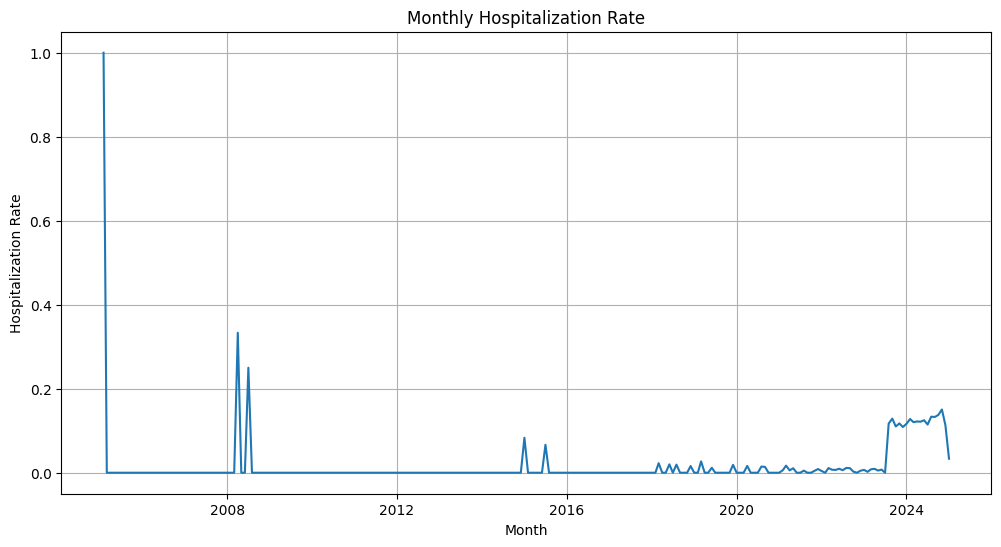


First rows of monthly rate:
  snapshot_month  hospital_admission_within_30_days
0     2005-02-01                                1.0
1     2005-03-01                                0.0
2     2005-04-01                                0.0
3     2005-05-01                                0.0
4     2005-06-01                                0.0


In [ ]:
# ------------------------------------------------------------
# 17. Monthly Hospitalization Trend
# ------------------------------------------------------------
# This block analyzes the monthly rate of hospitalization
# events across the entire panel dataset.
#
# It helps identify:
# - temporal drift
# - structural changes
# - data anomalies
# ------------------------------------------------------------

import matplotlib.pyplot as plt

monthly_rate = (
    panel
    .groupby("snapshot_month")["hospital_admission_within_30_days"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_rate["snapshot_month"],
    monthly_rate["hospital_admission_within_30_days"]
)

plt.title("Monthly Hospitalization Rate")
plt.xlabel("Month")
plt.ylabel("Hospitalization Rate")

plt.grid(True)

plt.show()

print("\nFirst rows of monthly rate:")
print(monthly_rate.head())


Top 15 most important features:
                                        feature  coefficient  abs_coefficient
23                days_since_resident_admission    -3.301036         3.301036
0                                    outpatient    -0.586320         0.586320
16          facility_incident_rate_last_30_days     0.360022         0.360022
10             facility_admissions_last_90_days     0.356730         0.356730
13                      facility_resident_count     0.350789         0.350789
15         facility_admission_rate_last_90_days     0.339002         0.339002
11              facility_incidents_last_30_days    -0.272180         0.272180
1                past_hospital_admissions_count     0.262652         0.262652
25                    days_since_last_admission     0.186038         0.186038
19  resident_vs_facility_admission_pressure_90d     0.183395         0.183395
27                          has_prior_admission    -0.128678         0.128678
6                      admissio

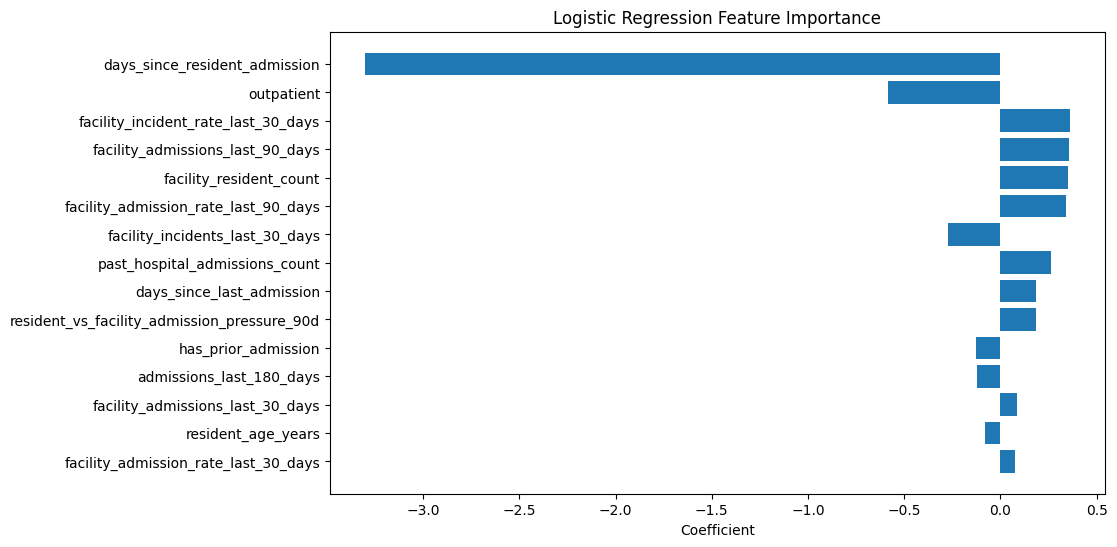

In [ ]:
# ------------------------------------------------------------
# 18. Logistic Regression Feature Importance
# ------------------------------------------------------------
# This block extracts the coefficients of the logistic model
# and ranks features by importance.
# ------------------------------------------------------------

import pandas as pd

# extract model
log_model = baseline_model.named_steps["model"]

coefficients = pd.DataFrame({
    "feature": selected_features,
    "coefficient": log_model.coef_[0]
})

coefficients["abs_coefficient"] = coefficients["coefficient"].abs()

coefficients = coefficients.sort_values(
    "abs_coefficient",
    ascending=False
)

print("\nTop 15 most important features:")
print(coefficients.head(15))


# ------------------------------------------------------------
# Plot feature importance
# ------------------------------------------------------------

import matplotlib.pyplot as plt

top_features = coefficients.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["coefficient"]
)

plt.gca().invert_yaxis()

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient")

plt.show()


Risk Decile Summary:
             residents  admissions  admission_rate
risk_decile                                       
1                  670         240        0.358209
2                  669         188        0.281016
3                  670         124        0.185075
4                  669          91        0.136024
5                  669          51        0.076233
6                  670          38        0.056716
7                  669          17        0.025411
8                  670          20        0.029851
9                  669          10        0.014948
10                 670           9        0.013433


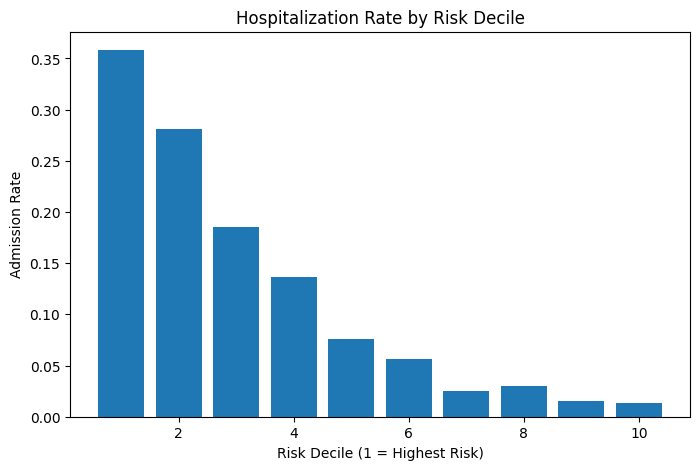

In [ ]:
# ------------------------------------------------------------
# 19. Risk Deciles Analysis
# ------------------------------------------------------------
# This block evaluates how well the model stratifies risk
# by dividing residents into risk deciles.
# ------------------------------------------------------------

import pandas as pd

# create deciles
valid_scored["risk_decile"] = pd.qcut(
    valid_scored["predicted_risk"],
    10,
    labels=False
)

# reverse order so decile 10 = highest risk
valid_scored["risk_decile"] = 10 - valid_scored["risk_decile"]

# compute hospitalization rate per decile
decile_summary = (
    valid_scored
    .groupby("risk_decile")
    .agg(
        residents=("resident_id", "count"),
        admissions=("hospital_admission_within_30_days", "sum"),
        admission_rate=("hospital_admission_within_30_days", "mean")
    )
    .sort_index()
)

print("\nRisk Decile Summary:")
print(decile_summary)

# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    decile_summary.index,
    decile_summary["admission_rate"]
)

plt.title("Hospitalization Rate by Risk Decile")
plt.xlabel("Risk Decile (1 = Highest Risk)")
plt.ylabel("Admission Rate")

plt.show()

#14. Gradient Boosting Model — LightGBM

In [ ]:
# ------------------------------------------------------------
# 20. Tree Model — LightGBM
# ------------------------------------------------------------
# Train a gradient boosting model to capture nonlinear effects
# ------------------------------------------------------------

from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# predictions
train_pred_lgb = lgb_model.predict_proba(X_train)[:,1]
valid_pred_lgb = lgb_model.predict_proba(X_valid)[:,1]

[LightGBM] [Info] Number of positive: 1296, number of negative: 23762
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2254
[LightGBM] [Info] Number of data points in the train set: 25058, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.051720 -> initscore=-2.908805
[LightGBM] [Info] Start training from score -2.908805
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [ ]:
# ------------------------------------------------------------
# 21. Evaluate LightGBM Model
# ------------------------------------------------------------

from sklearn.metrics import roc_auc_score, average_precision_score

roc_train = roc_auc_score(y_train, train_pred_lgb)
roc_valid = roc_auc_score(y_valid, valid_pred_lgb)

pr_train = average_precision_score(y_train, train_pred_lgb)
pr_valid = average_precision_score(y_valid, valid_pred_lgb)

print("\n==============================")
print("LIGHTGBM RESULTS")
print("==============================")

print(f"ROC-AUC Train:      {roc_train:.4f}")
print(f"ROC-AUC Validation: {roc_valid:.4f}")

print(f"\nPR-AUC Train:      {pr_train:.4f}")
print(f"PR-AUC Validation: {pr_valid:.4f}")


LIGHTGBM RESULTS
ROC-AUC Train:      0.9928
ROC-AUC Validation: 0.9183

PR-AUC Train:      0.9295
PR-AUC Validation: 0.7570



Top 15 LightGBM Features:
                                        feature  importance
23                           resident_age_years        1891
24                days_since_resident_admission        1730
14                      facility_resident_count        1069
26                    days_since_last_admission         934
16         facility_admission_rate_last_90_days         873
20  resident_vs_facility_admission_pressure_90d         780
15         facility_admission_rate_last_30_days         729
19   resident_vs_facility_incident_pressure_90d         660
17          facility_incident_rate_last_30_days         658
18          facility_incident_rate_last_90_days         634
11             facility_admissions_last_90_days         606
13              facility_incidents_last_90_days         467
25                     days_since_last_incident         445
10             facility_admissions_last_30_days         334
12              facility_incidents_last_30_days         301


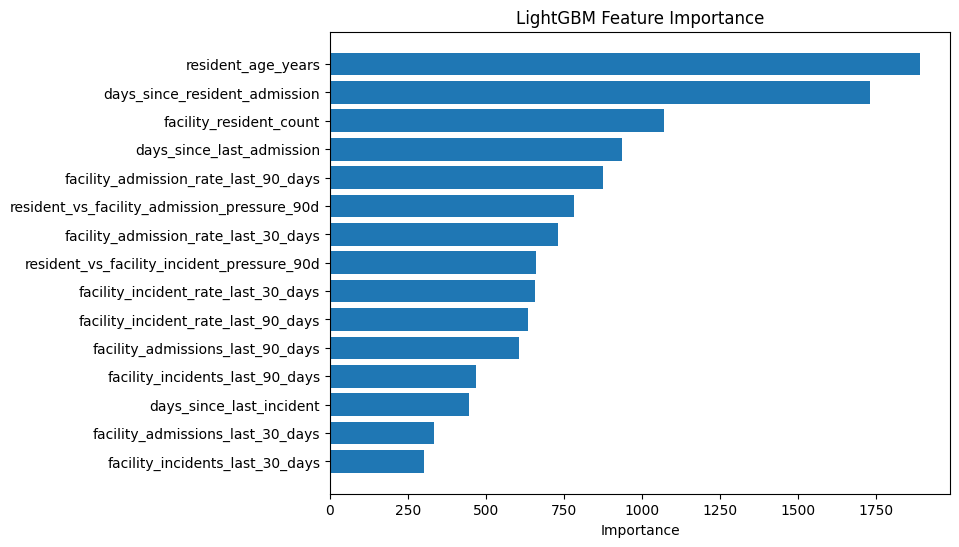

In [ ]:
# ------------------------------------------------------------
# 22. LightGBM Feature Importance
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

print("\nTop 15 LightGBM Features:")
print(importance.head(15))

plt.figure(figsize=(8,6))

plt.barh(
    importance.head(15)["feature"][::-1],
    importance.head(15)["importance"][::-1]
)

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")

plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP values shape: (6695, 29)


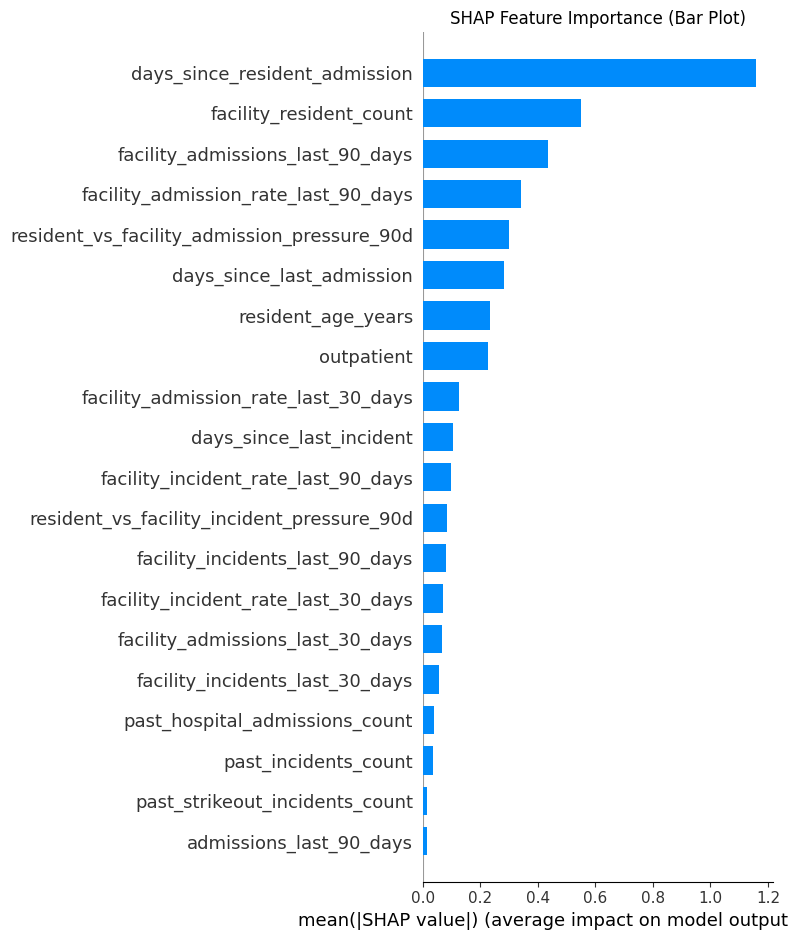

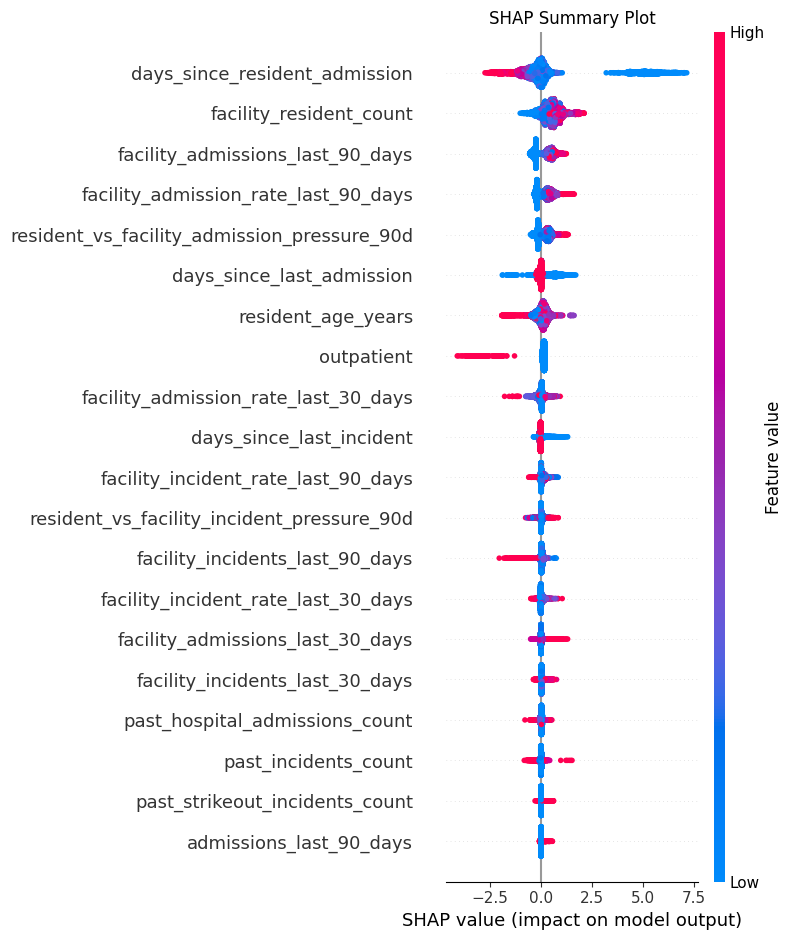

In [ ]:
# ------------------------------------------------------------
# 23. SHAP Explainability for LightGBM
# ------------------------------------------------------------
# This block computes SHAP values for the LightGBM model in
# order to explain which features are driving predictions.
#
# Outputs:
# - SHAP summary bar plot
# - SHAP beeswarm plot
# ------------------------------------------------------------

# Install SHAP if needed
try:
    import shap
except ImportError:
    !pip install shap -q
    import shap

import shap
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create SHAP explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(lgb_model)

# ------------------------------------------------------------
# 2. Compute SHAP values on validation set
# ------------------------------------------------------------
# We explain the validation set because it represents the
# future period and is more relevant for interpretation.
# ------------------------------------------------------------

shap_values = explainer.shap_values(X_valid)

# ------------------------------------------------------------
# 3. Handle binary classification output
# ------------------------------------------------------------
# Depending on SHAP / LightGBM version, shap_values may come as:
# - a list with one array per class
# - a single array
#
# We keep the positive-class explanation.
# ------------------------------------------------------------

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

print("SHAP values shape:", shap_values_to_plot.shape)

# ------------------------------------------------------------
# 4. SHAP summary bar plot
# ------------------------------------------------------------
# Shows which features contribute the most globally.
# ------------------------------------------------------------

plt.figure()
shap.summary_plot(
    shap_values_to_plot,
    X_valid,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (Bar Plot)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. SHAP beeswarm plot
# ------------------------------------------------------------
# Shows direction and magnitude of impact for each feature.
# ------------------------------------------------------------

plt.figure()
shap.summary_plot(
    shap_values_to_plot,
    X_valid,
    show=False
)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

#15. Model Comparison

In [ ]:
# ------------------------------------------------------------
# 24. Model Comparison
# ------------------------------------------------------------
# Compare Logistic Regression (baseline) vs LightGBM
# ------------------------------------------------------------

import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# Logistic predictions (already created earlier)
log_train_pred = train_scored["predicted_risk"]
log_valid_pred = valid_scored["predicted_risk"]

# LightGBM predictions
lgb_train_pred = train_pred_lgb
lgb_valid_pred = valid_pred_lgb

# Logistic metrics
roc_log_train = roc_auc_score(y_train, log_train_pred)
roc_log_valid = roc_auc_score(y_valid, log_valid_pred)

pr_log_train = average_precision_score(y_train, log_train_pred)
pr_log_valid = average_precision_score(y_valid, log_valid_pred)

# LightGBM metrics
roc_lgb_train = roc_auc_score(y_train, lgb_train_pred)
roc_lgb_valid = roc_auc_score(y_valid, lgb_valid_pred)

pr_lgb_train = average_precision_score(y_train, lgb_train_pred)
pr_lgb_valid = average_precision_score(y_valid, lgb_valid_pred)

# Build comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "LightGBM"],
    "ROC-AUC Train": [roc_log_train, roc_lgb_train],
    "ROC-AUC Validation": [roc_log_valid, roc_lgb_valid],
    "PR-AUC Train": [pr_log_train, pr_lgb_train],
    "PR-AUC Validation": [pr_log_valid, pr_lgb_valid]
})

print("\nModel Comparison:")
display(comparison)


Model Comparison:


,Model,ROC-AUC Train,ROC-AUC Validation,PR-AUC Train,PR-AUC Validation
0,Logistic Regression,0.907540,0.796734,0.348317,0.316341
1,LightGBM,0.992802,0.918310,0.929453,0.757007


# 16. Project Conclusions

## Objective

The goal of this project was to develop a machine learning model capable of predicting the risk of **hospital admission within the next 30 days** for residents in assisted living facilities.

This type of risk model can help healthcare providers:

- identify high-risk residents
- prioritize preventive interventions
- reduce avoidable hospitalizations
- improve care quality and resource allocation.

---

## Modeling Approach

The project followed a structured machine learning workflow:

1. **Data preparation and feature engineering**

Features were created to capture:

- resident clinical history
- recent incidents and admissions
- facility-level pressure indicators
- time since key clinical events

Examples:

- `days_since_resident_admission`
- `facility_admission_rate_last_90_days`
- `resident_vs_facility_admission_pressure_90d`

---

2. **Time-based validation**

A **time-based train/validation split** was used to simulate real-world deployment and avoid data leakage.

---

3. **Baseline model**

A Logistic Regression model was trained as a baseline.

Results:

- ROC-AUC ≈ 0.79
- PR-AUC ≈ 0.31

The model already showed good risk stratification ability.

---

4. **Tree-based model**

A LightGBM model was then trained to capture nonlinear relationships and feature interactions.

Results:

- ROC-AUC ≈ 0.92
- PR-AUC ≈ 0.76

This represents a significant improvement over the baseline.

---

## Risk Stratification

The model successfully stratified residents into meaningful risk groups.

Example:

| Risk Decile | Admission Rate |
|--------------|----------------|
| Top 10% risk | ~36% |
| Bottom 10% risk | ~1.3% |

This indicates that the model effectively concentrates hospitalizations in the highest-risk groups.

---

## Model Explainability

SHAP values were used to interpret the LightGBM model.

The most influential features included:

- `days_since_resident_admission`
- `facility_resident_count`
- `facility_admission_rate_last_90_days`
- `resident_vs_facility_admission_pressure_90d`
- `days_since_last_admission`

These variables reflect both **resident clinical history** and **facility-level pressure**, which are clinically plausible drivers of hospitalization risk.

---

## Key Takeaways

- Time since admission and recent clinical events are strong predictors of hospitalization.
- Facility-level dynamics also significantly influence resident risk.
- Tree-based models substantially improve predictive performance over linear baselines.
- Explainability techniques such as SHAP help validate that the model is learning meaningful clinical patterns.

---

## Potential Next Steps

Possible future improvements could include:

- incorporating additional clinical variables
- calibrating predicted probabilities
- deploying the model as a real-time risk scoring tool
- integrating predictions into clinical decision support systems